#  THIS CODE DOCUMENT IS FOR THESIS MODELS" 
Machine Learning in Football prediction for the Begian Jupiler League

In [161]:
# Data Manipulation and Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries

# Preprocessing and Feature Selection
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# Model Selection and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Verify that all packages are imported correctly
print("All packages imported successfully.")


All packages imported successfully.


In [162]:
import sys
import pandas
import numpy
import sklearn
import xgboost
import seaborn

print("Python version:", sys.version)
print("pandas version:", pandas.__version__)
print("numpy version:", numpy.__version__)
print("scikit-learn version:", sklearn.__version__)
print("xgboost version:", xgboost.__version__)
print("seaborn version:", seaborn.__version__)


Python version: 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
pandas version: 2.1.4
numpy version: 1.26.3
scikit-learn version: 1.5.1
xgboost version: 2.1.1
seaborn version: 0.13.2


In [163]:

# Reading the datasets (assuming they are CSV files)

B1920 = pd.read_csv('B1920.csv')
B2021 = pd.read_csv('B2021.csv')
B2122 = pd.read_csv('B2122.csv')
B2223 = pd.read_csv('B2223.csv')
B2324 = pd.read_csv('B2324.csv')



In [164]:

print(f'2019/2020 season shape: {B1920.shape}')
print(f'2020/2021 season shape: {B2021.shape}')
print(f'2021/2022 season shape: {B2122.shape}')
print(f'2022/2023 season shape: {B2223.shape}')
print(f'2023/2024 season shape: {B2324.shape}')

2019/2020 season shape: (232, 105)
2020/2021 season shape: (306, 105)
2021/2022 season shape: (306, 106)
2022/2023 season shape: (306, 105)
2023/2024 season shape: (312, 105)


the data retrived from football.co.uk shows dissimilarities  accross the different years considered on the total number of matches played. 
-2018/2019 season had 240 games played 
-2019/2020 season had  232 games played
-2020/2021, 2021/2022, 2022/2023 all had 306 games played.
-2023/2024 season had 312 games played

**The differene in total number of games will be invegated and if need be will be adjusted.**

# Merging  datasets
 the 6 season datasets is combined into on main dataset  for further analyis and exploration.

In [165]:
# List of DataFrames
dfs = [ B1920, B2021, B2122, B2223, B2324]

# Concatenate the DataFrames vertically (one below the other)
merged_data = pd.concat(dfs, ignore_index=True)


# Display the merged dataset
merged_data.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Unnamed: 105
0,B1,26/07/2019,19:30,Genk,Kortrijk,2,1,H,0.0,1.0,...,-1.25,1.98,1.88,2.01,1.88,2.05,1.96,1.96,1.87,NaN
1,B1,27/07/2019,17:00,Cercle Brugge,Standard,0,2,A,0.0,0.0,...,0.50,1.88,1.98,1.91,1.99,1.95,2.02,1.89,1.94,NaN
2,B1,27/07/2019,19:00,St Truiden,Mouscron,0,1,A,0.0,1.0,...,-0.25,1.83,2.02,1.87,2.03,1.88,2.07,1.83,2.02,NaN
3,B1,27/07/2019,19:00,Waregem,Mechelen,0,2,A,0.0,1.0,...,0.25,1.72,2.07,1.75,2.17,1.80,2.28,1.72,2.15,NaN
4,B1,27/07/2019,19:30,Waasland-Beveren,Club Brugge,1,3,A,1.0,1.0,...,1.50,2.20,1.70,2.19,1.74,2.25,1.83,2.11,1.74,NaN


In [166]:
merged_data.shape

(1462, 106)

Removing irrelevant columns from the dataset

In [167]:



# Find the index position of the 'B365A' column
ar_index = merged_data.columns.get_loc('B365A')

# Select all columns up to and including 'AR'
merged_data = merged_data.iloc[:, :ar_index + 1]
# Drop the specified columns
merged_data.drop(columns=['HTHG', 'HTAG', 'HTR'], inplace=True)

merged_data.columns

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR',
       'AR', 'B365H', 'B365D', 'B365A'],
      dtype='object')

In [168]:
# Convert 'Date' column to datetime dtype
merged_data['Date'] = pd.to_datetime(
    merged_data['Date'], dayfirst=True, errors='coerce'
)

# Convert 'Time' column to datetime and extract the hour
merged_data['Hour'] = pd.to_datetime(
    merged_data['Time'], format='%H:%M', errors='coerce'
).dt.hour


# Step 3: Verify the data types

merged_data.dtypes

Div                 object
Date        datetime64[ns]
Time                object
HomeTeam            object
AwayTeam            object
FTHG                 int64
FTAG                 int64
FTR                 object
HS                 float64
AS                 float64
HST                float64
AST                float64
HF                 float64
AF                 float64
HC                 float64
AC                 float64
HY                 float64
AY                 float64
HR                 float64
AR                 float64
B365H              float64
B365D              float64
B365A              float64
Hour                 int32
dtype: object

In [169]:
merged_data.shape

(1462, 24)

In [170]:
# Percentage of missing values
missing_percent = (merged_data.isnull().sum() / merged_data.shape[0]) * 100
missing_percent[missing_percent > 0]


HS       0.341997
AS       0.341997
HST      0.341997
AST      0.341997
HF       0.341997
AF       0.341997
HC       0.341997
AC       0.341997
HY       0.273598
AY       0.273598
HR       0.273598
AR       0.273598
B365H    0.068399
B365D    0.068399
B365A    0.068399
dtype: float64

Strategy:

If missing values are few, we can drop those rows.

If missing values are significant, we may need to impute them.  that get the results from online sources

# 4. Data Preprocessing
4.1. Converting 'Date' to Datetime and Extracting 'Hour'

In [171]:
# Convert 'Date' to datetime
merged_data['Date'] = pd.to_datetime(merged_data['Date'], dayfirst=True, errors='coerce')

# Extract 'Hour' from 'Time' and convert to integer
merged_data['Hour'] = pd.to_datetime(merged_data['Time'], format='%H:%M', errors='coerce').dt.hour

# Drop 'Time' column
merged_data.drop(columns=['Time'], inplace=True)


### Encoding the Target Variable 'FTR'

In [172]:
# Check unique values in 'FTR'
merged_data['FTR'].unique()


array(['H', 'A', 'D'], dtype=object)

In [173]:
# Map 'FTR' to numerical values
ftr_mapping = {'H': 1, 'D': 0, 'A': 2}
merged_data['FTR_numeric'] = merged_data['FTR'].map(ftr_mapping)


Extracting Additional Date Features

In [174]:
# Extract year, month, day, and day of the week
merged_data['Year'] = merged_data['Date'].dt.year
merged_data['Month'] = merged_data['Date'].dt.month
merged_data['Day'] = merged_data['Date'].dt.day
merged_data['DayOfWeek'] = merged_data['Date'].dt.day_name()


## 4.5. Handling Categorical Variables

In [175]:
# List of categorical variables
categorical_vars = ['Div', 'HomeTeam', 'AwayTeam', 'DayOfWeek']

# Display unique values for each categorical variable
for var in categorical_vars:
    print(f"\nUnique values in {var}: {merged_data[var].nunique()}")



Unique values in Div: 1

Unique values in HomeTeam: 22

Unique values in AwayTeam: 22

Unique values in DayOfWeek: 7


Encoding Categorical Variables:

Div: If there is only one division, encoding is not necessary.
HomeTeam and AwayTeam: We can use Label Encoding or One-Hot Encoding.
For teams, since there may be many unique values, Label Encoding is preferable.

In [176]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoders
le_home = LabelEncoder()
le_away = LabelEncoder()

# Encode 'HomeTeam' and 'AwayTeam'
merged_data['HomeTeam_enc'] = le_home.fit_transform(merged_data['HomeTeam'])
merged_data['AwayTeam_enc'] = le_away.fit_transform(merged_data['AwayTeam'])


In [177]:
merged_data.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,B365D,B365A,Hour,FTR_numeric,Year,Month,Day,DayOfWeek,HomeTeam_enc,AwayTeam_enc
0,B1,2019-07-26,Genk,Kortrijk,2,1,H,10.0,8.0,2.0,...,4.75,8.50,19,1,2019,7,26,Friday,7,9
1,B1,2019-07-27,Cercle Brugge,Standard,0,2,A,13.0,14.0,5.0,...,3.75,1.85,17,2,2019,7,27,Saturday,3,18
2,B1,2019-07-27,St Truiden,Mouscron,0,1,A,10.0,10.0,4.0,...,3.75,3.75,19,2,2019,7,27,Saturday,16,11
3,B1,2019-07-27,Waregem,Mechelen,0,2,A,7.0,10.0,2.0,...,3.60,3.10,19,2,2019,7,27,Saturday,20,10
4,B1,2019-07-27,Waasland-Beveren,Club Brugge,1,3,A,7.0,25.0,2.0,...,4.00,1.50,19,2,2019,7,27,Saturday,19,5


In [178]:
merged_data.columns

Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS',
       'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR',
       'B365H', 'B365D', 'B365A', 'Hour', 'FTR_numeric', 'Year', 'Month',
       'Day', 'DayOfWeek', 'HomeTeam_enc', 'AwayTeam_enc'],
      dtype='object')

Encode 'DayOfWeek' using One-Hot Encoding.

In [179]:
# 4.4. Handling Categorical Variables

# Extract day of the week
merged_data['DayOfWeek'] = merged_data['Date'].dt.day_name()

# Map 'DayOfWeek' to numerical values
day_mapping = {
    'Sunday': 1,
    'Monday': 2,
    'Tuesday': 3,
    'Wednesday': 4,
    'Thursday': 5,
    'Friday': 6,
    'Saturday': 7
}

merged_data['DayOfWeek_Num'] = merged_data['DayOfWeek'].map(day_mapping)

# Drop the original 'DayOfWeek' column
merged_data.drop(columns=['DayOfWeek'], inplace=True)


# Correlation Analysis

In [180]:
# Drop the 'Div' column
merged_data_numeric = merged_data.drop('Div', axis=1)



Observation:

Identify features with high correlation to 'FTR_numeric'.

# Feature engineering

Here we use the already known features to generate new features to help  predict the current match.

# computing rolling averaages to know more about the teams recent form 

Identifying Numerical Variables

First, list all the numerical variables for which you want to calculate rolling averages. Based on your dataset, the numerical variables are:

Goals:

FTHG: Full-Time Home Goals

FTAG: Full-Time Away Goals

Shots:

HS: Home Shots

AS: Away Shots

HST: Home Shots on Target

AST: Away Shots on Target

Fouls:

HF: Home Fouls

AF: Away Fouls

Corners:

HC: Home Corners

AC: Away Corners

Cards:

HY: Home Yellow Cards

AY: Away Yellow Cards

HR: Home Red Cards

AR: Away Red Cards

Data Preparation

3.1. Create a Unique Match ID

We need a unique identifier for each match to merge data later.

In [181]:
# Create a unique Match ID
merged_data['MatchID'] = merged_data.index


3.2. Reshape the Data

We'll transform the dataset into a long format where each row represents a team's performance in a match, whether they played at home or away.

3.2.1. Home Team Data

In [182]:
# Prepare home team data
home_stats = merged_data[['MatchID', 'Date', 'HomeTeam', 'FTHG', 'FTAG', 'HS', 'HST', 'HF', 'HC', 'HY', 'HR', 'AS', 'AST', 'AF', 'AC', 'AY', 'AR']]
home_stats = home_stats.rename(columns={
    'HomeTeam': 'Team',
    'FTHG': 'GoalsFor',
    'FTAG': 'GoalsAgainst',
    'HS': 'ShotsFor',
    'AS': 'ShotsAgainst',
    'HST': 'ShotsOnTargetFor',
    'AST': 'ShotsOnTargetAgainst',
    'HF': 'FoulsFor',
    'AF': 'FoulsAgainst',
    'HC': 'CornersFor',
    'AC': 'CornersAgainst',
    'HY': 'YellowCardsFor',
    'AY': 'YellowCardsAgainst',
    'HR': 'RedCardsFor',
    'AR': 'RedCardsAgainst'
})
home_stats['HomeAway'] = 'Home'


Away Team Data 

In [183]:
# Prepare away team data
away_stats = merged_data[['MatchID', 'Date', 'AwayTeam', 'FTAG', 'FTHG', 'AS', 'AST', 'AF', 'AC', 'AY', 'AR', 'HS', 'HST', 'HF', 'HC', 'HY', 'HR']]
away_stats = away_stats.rename(columns={
    'AwayTeam': 'Team',
    'FTAG': 'GoalsFor',
    'FTHG': 'GoalsAgainst',
    'AS': 'ShotsFor',
    'HS': 'ShotsAgainst',
    'AST': 'ShotsOnTargetFor',
    'HST': 'ShotsOnTargetAgainst',
    'AF': 'FoulsFor',
    'HF': 'FoulsAgainst',
    'AC': 'CornersFor',
    'HC': 'CornersAgainst',
    'AY': 'YellowCardsFor',
    'HY': 'YellowCardsAgainst',
    'AR': 'RedCardsFor',
    'HR': 'RedCardsAgainst'
})
away_stats['HomeAway'] = 'Away'


3.2.3. Combine Home and Away Data

In [184]:
# Combine home and away data
team_stats = pd.concat([home_stats, away_stats], ignore_index=True)


3.3. Sort Data by Team and Date

This is crucial for calculating rolling averages in the correct order.

In [185]:
# Sort by Team and Date
team_stats.sort_values(by=['Team', 'Date'], inplace=True)


4. Calculating Rolling Averages

4.1. Define Numerical Variables

In [186]:
numerical_vars = ['GoalsFor', 'GoalsAgainst', 'ShotsFor', 'ShotsAgainst', 'ShotsOnTargetFor', 'ShotsOnTargetAgainst',
                  'FoulsFor', 'FoulsAgainst', 'CornersFor', 'CornersAgainst', 'YellowCardsFor', 'YellowCardsAgainst',
                  'RedCardsFor', 'RedCardsAgainst']


4.2. Compute Rolling Averages

We will compute the rolling mean over a window of 3 matches, shifted by 1 to exclude the current match (to prevent data leakage).

In [187]:
# Compute rolling averages using transform
team_stats[numerical_vars] = team_stats.groupby('Team')[numerical_vars].transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)




groupby('Team'): Groups the data by each team.

shift(1): Shifts the data by one to exclude the current match from the calculation.

rolling(window=3).mean(): Calculates the mean over the last 3 matches.

5. Merging Rolling Averages Back to the Main Dataset

5.1. Separate Home and Away Rolling Stats

Home Team Rolling Stats

In [188]:
# Home team rolling stats
home_rolling_stats = team_stats[team_stats['HomeAway'] == 'Home']
home_rolling_stats = home_rolling_stats.rename(columns={var: 'HomeTeam_' + var + '_roll3' for var in numerical_vars})
home_rolling_stats = home_rolling_stats[['MatchID'] + [col for col in home_rolling_stats.columns if 'HomeTeam_' in col]]


Away Team Rolling Stats

In [189]:
# Away team rolling stats
away_rolling_stats = team_stats[team_stats['HomeAway'] == 'Away']
away_rolling_stats = away_rolling_stats.rename(columns={var: 'AwayTeam_' + var + '_roll3' for var in numerical_vars})
away_rolling_stats = away_rolling_stats[['MatchID'] + [col for col in away_rolling_stats.columns if 'AwayTeam_' in col]]


5.2. Merge Rolling Stats into the Main DataFrame

In [190]:
# Merge home rolling stats
merged_data = merged_data.merge(home_rolling_stats, on='MatchID', how='left')

# Merge away rolling stats
merged_data = merged_data.merge(away_rolling_stats, on='MatchID', how='left')


6. Handling Missing Values

The rolling averages for the first few matches of each team will be NaN due to insufficient previous matches. You can choose to:


Leave them as NaN.

Fill them with a default value (e.g., 0 or the overall mean).

Remove these matches from the dataset if appropriate.

For now, we'll leave them as NaN.

8. Verifying the Results

Check the first few rows to ensure the rolling averages have been calculated correctly.

In [191]:
# Display sample of the merged data
merged_data[['Date', 'HomeTeam', 'AwayTeam', 'HomeTeam_GoalsFor_roll3', 'AwayTeam_GoalsFor_roll3']].head(20)


,Date,HomeTeam,AwayTeam,HomeTeam_GoalsFor_roll3,AwayTeam_GoalsFor_roll3
0,2019-07-26,Genk,Kortrijk,NaN,NaN
1,2019-07-27,Cercle Brugge,Standard,NaN,NaN
2,2019-07-27,St Truiden,Mouscron,NaN,NaN
3,2019-07-27,Waregem,Mechelen,NaN,NaN
4,2019-07-27,Waasland-Beveren,Club Brugge,NaN,NaN
5,2019-07-28,Anderlecht,Oostende,NaN,NaN
6,2019-07-28,Charleroi,Gent,NaN,NaN
7,2019-07-28,Eupen,Antwerp,NaN,NaN
8,2019-08-02,Club Brugge,St Truiden,NaN,NaN
9,2019-08-03,Standard,Waregem,NaN,NaN


Notes and Considerations

Data Leakage: The shift(1) ensures that only past matches are used in the calculation, preventing data leakage.

Missing Values: The first two matches for each team will have NaN values for the rolling averages due to insufficient data.

Feature Scaling: Consider scaling the new features if needed, especially if you're using algorithms sensitive to feature scaling.

Additional Features: You can adjust the window size or include more variables as per your analysis needs.

10. Conclusion

By following this approach, you've successfully created rolling average features for each team based on their last 3 matches, considering

both home and away games. These features can provide valuable insights into a team's recent form and enhance the predictive power of your 

machine learning models.



##  Repeations

In [192]:
# 0. Make a copy of merged_data
merged_data_copy = merged_data.copy()

# 1. Identify Numerical Variables
numerical_vars = [
    'GoalsFor', 'GoalsAgainst', 'ShotsFor', 'ShotsAgainst',
    'ShotsOnTargetFor', 'ShotsOnTargetAgainst', 'FoulsFor', 'FoulsAgainst',
    'CornersFor', 'CornersAgainst', 'YellowCardsFor', 'YellowCardsAgainst',
    'RedCardsFor', 'RedCardsAgainst'
]

# 2. Create Unique Match ID
merged_data_copy['MatchID'] = merged_data_copy.index

# 3. Prepare Home and Away Team Data
# Home Team Data
home_stats = merged_data_copy[[
    'MatchID', 'Date', 'HomeTeam', 'FTHG', 'FTAG', 'HS', 'HST', 'HF', 'HC', 'HY', 'HR',
    'AS', 'AST', 'AF', 'AC', 'AY', 'AR'
]]
home_stats = home_stats.rename(columns={
    'HomeTeam': 'Team',
    'FTHG': 'GoalsFor',
    'FTAG': 'GoalsAgainst',
    'HS': 'ShotsFor',
    'AS': 'ShotsAgainst',
    'HST': 'ShotsOnTargetFor',
    'AST': 'ShotsOnTargetAgainst',
    'HF': 'FoulsFor',
    'AF': 'FoulsAgainst',
    'HC': 'CornersFor',
    'AC': 'CornersAgainst',
    'HY': 'YellowCardsFor',
    'AY': 'YellowCardsAgainst',
    'HR': 'RedCardsFor',
    'AR': 'RedCardsAgainst'
})
home_stats['HomeAway'] = 'Home'

# Away Team Data
away_stats = merged_data_copy[[
    'MatchID', 'Date', 'AwayTeam', 'FTAG', 'FTHG', 'AS', 'AST', 'AF', 'AC', 'AY', 'AR',
    'HS', 'HST', 'HF', 'HC', 'HY', 'HR'
]]
away_stats = away_stats.rename(columns={
    'AwayTeam': 'Team',
    'FTAG': 'GoalsFor',
    'FTHG': 'GoalsAgainst',
    'AS': 'ShotsFor',
    'HS': 'ShotsAgainst',
    'AST': 'ShotsOnTargetFor',
    'HST': 'ShotsOnTargetAgainst',
    'AF': 'FoulsFor',
    'HF': 'FoulsAgainst',
    'AC': 'CornersFor',
    'HC': 'CornersAgainst',
    'AY': 'YellowCardsFor',
    'HY': 'YellowCardsAgainst',
    'AR': 'RedCardsFor',
    'HR': 'RedCardsAgainst'
})
away_stats['HomeAway'] = 'Away'

# Combine Data
team_stats = pd.concat([home_stats, away_stats], ignore_index=True)

# 4. Ensure 'Date' is datetime and Sort by Team and Date
team_stats['Date'] = pd.to_datetime(team_stats['Date'])
team_stats.sort_values(by=['Team', 'Date'], inplace=True)

# 5. Compute Rolling Averages Using Transform
team_stats[numerical_vars] = team_stats.groupby('Team')[numerical_vars].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)

# 6. Separate Home and Away Rolling Stats
# Home Team Rolling Stats
home_rolling_stats = team_stats[team_stats['HomeAway'] == 'Home'].copy()
home_rolling_stats.rename(columns={var: 'HomeTeam_' + var + '_roll3' for var in numerical_vars}, inplace=True)
home_rolling_stats = home_rolling_stats[['MatchID'] + [col for col in home_rolling_stats.columns if col.startswith('HomeTeam_')]]

# Away Team Rolling Stats
away_rolling_stats = team_stats[team_stats['HomeAway'] == 'Away'].copy()
away_rolling_stats.rename(columns={var: 'AwayTeam_' + var + '_roll3' for var in numerical_vars}, inplace=True)
away_rolling_stats = away_rolling_stats[['MatchID'] + [col for col in away_rolling_stats.columns if col.startswith('AwayTeam_')]]

# 7. Check for Overlapping Columns Before Merging
# Identify overlapping columns with home rolling stats
overlapping_home = set(merged_data_copy.columns).intersection(set(home_rolling_stats.columns)) - {'MatchID'}

# Identify overlapping columns with away rolling stats
overlapping_away = set(merged_data_copy.columns).intersection(set(away_rolling_stats.columns)) - {'MatchID'}

# Drop overlapping columns from merged_data_copy
if overlapping_home:
    print(f"Dropping overlapping columns before merging home rolling stats: {overlapping_home}")
    merged_data_copy.drop(columns=overlapping_home, inplace=True)

if overlapping_away:
    print(f"Dropping overlapping columns before merging away rolling stats: {overlapping_away}")
    merged_data_copy.drop(columns=overlapping_away, inplace=True)

# 8. Merge Rolling Stats into Main DataFrame
# Merge home rolling stats
merged_data_copy = merged_data_copy.merge(home_rolling_stats, on='MatchID', how='left')

# Merge away rolling stats
merged_data_copy = merged_data_copy.merge(away_rolling_stats, on='MatchID', how='left')

# 9. Verify the Results
# Check for any columns with '_x' or '_y' suffixes
duplicate_columns = [col for col in merged_data_copy.columns if col.endswith('_x') or col.endswith('_y')]
print(f'Duplicate columns after merging: {duplicate_columns}')



Dropping overlapping columns before merging home rolling stats: {'HomeTeam_FoulsAgainst_roll3', 'HomeTeam_GoalsAgainst_roll3', 'HomeTeam_ShotsAgainst_roll3', 'HomeTeam_ShotsOnTargetFor_roll3', 'HomeTeam_CornersFor_roll3', 'HomeTeam_ShotsFor_roll3', 'HomeTeam_RedCardsAgainst_roll3', 'HomeTeam_FoulsFor_roll3', 'HomeTeam_ShotsOnTargetAgainst_roll3', 'HomeTeam_YellowCardsAgainst_roll3', 'HomeTeam_GoalsFor_roll3', 'HomeTeam_YellowCardsFor_roll3', 'HomeTeam_CornersAgainst_roll3', 'HomeTeam_RedCardsFor_roll3'}
Dropping overlapping columns before merging away rolling stats: {'AwayTeam_ShotsOnTargetFor_roll3', 'AwayTeam_GoalsAgainst_roll3', 'AwayTeam_CornersAgainst_roll3', 'AwayTeam_GoalsFor_roll3', 'AwayTeam_FoulsAgainst_roll3', 'AwayTeam_RedCardsAgainst_roll3', 'AwayTeam_YellowCardsAgainst_roll3', 'AwayTeam_ShotsFor_roll3', 'AwayTeam_FoulsFor_roll3', 'AwayTeam_ShotsAgainst_roll3', 'AwayTeam_RedCardsFor_roll3', 'AwayTeam_CornersFor_roll3', 'AwayTeam_ShotsOnTargetAgainst_roll3', 'AwayTeam_Yello

In [193]:
# Display sample of the merged data
display_columns = [
    'Date', 'HomeTeam', 'AwayTeam',
    'HomeTeam_GoalsFor_roll3', 'HomeTeam_GoalsAgainst_roll3',
    'AwayTeam_GoalsFor_roll3', 'AwayTeam_GoalsAgainst_roll3'
]
(merged_data_copy[display_columns].head(20))


,Date,HomeTeam,AwayTeam,HomeTeam_GoalsFor_roll3,HomeTeam_GoalsAgainst_roll3,AwayTeam_GoalsFor_roll3,AwayTeam_GoalsAgainst_roll3
0,2019-07-26,Genk,Kortrijk,NaN,NaN,NaN,NaN
1,2019-07-27,Cercle Brugge,Standard,NaN,NaN,NaN,NaN
2,2019-07-27,St Truiden,Mouscron,NaN,NaN,NaN,NaN
3,2019-07-27,Waregem,Mechelen,NaN,NaN,NaN,NaN
4,2019-07-27,Waasland-Beveren,Club Brugge,NaN,NaN,NaN,NaN
5,2019-07-28,Anderlecht,Oostende,NaN,NaN,NaN,NaN
6,2019-07-28,Charleroi,Gent,NaN,NaN,NaN,NaN
7,2019-07-28,Eupen,Antwerp,NaN,NaN,NaN,NaN
8,2019-08-02,Club Brugge,St Truiden,3.0,1.0,0.0,1.0
9,2019-08-03,Standard,Waregem,2.0,0.0,0.0,2.0


# Unsupervised Learning 

Unsupervised learning algorithms can help:

Identify Patterns and Groupings: Discover natural groupings among teams or matches based on performance metrics.

Reduce Dimensionality: Simplify your dataset while retaining most of the variance, making it easier to visualize and analyze.

Detect Anomalies: Find outliers or unusual matches that deviate from typical patterns.

# Clustering Teams Based on Performance Metrics

Clustering can help you group teams with similar performance characteristics. This can reveal insights such as:

Identifying teams with similar playing styles.

Grouping teams based on recent performance trends.

Understanding the competitive landscape.

# Preparing the Data

  the rolling average features  previously calculated will be used as they represent recent team performance.

Step 1: Select Features for Clustering

In [194]:
# List of features to use for clustering
clustering_features = [
    'HomeTeam_GoalsFor_roll3', 'HomeTeam_GoalsAgainst_roll3',
    'HomeTeam_ShotsFor_roll3', 'HomeTeam_ShotsAgainst_roll3',
    'HomeTeam_ShotsOnTargetFor_roll3', 'HomeTeam_ShotsOnTargetAgainst_roll3',
    'HomeTeam_CornersFor_roll3', 'HomeTeam_CornersAgainst_roll3',
    'AwayTeam_GoalsFor_roll3', 'AwayTeam_GoalsAgainst_roll3',
    'AwayTeam_ShotsFor_roll3', 'AwayTeam_ShotsAgainst_roll3',
    'AwayTeam_ShotsOnTargetFor_roll3', 'AwayTeam_ShotsOnTargetAgainst_roll3',
    'AwayTeam_CornersFor_roll3', 'AwayTeam_CornersAgainst_roll3'
]

# Drop rows with missing values in clustering features
clustering_data = merged_data_copy.dropna(subset=clustering_features)

# Features matrix
X = clustering_data[clustering_features]


 using both home and away rolling averages to capture overall team performance.

dropped  rows with missing values to ensure the clustering algorithm works properly.

Step 2: Standardize the Features
Clustering algorithms are sensitive to the scale of the data. We need to standardize the features.

In [195]:
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# K-Means Clustering

Step 1: Determine the Optimal Number of Clusters

We can use the Elbow Method to determine the optimal number of clusters.

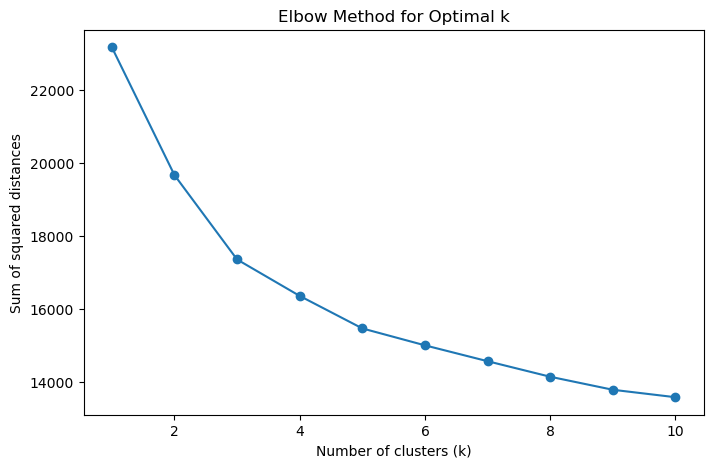

In [196]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow method to find optimal k
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of squared distances')
plt.show()


Sum of Squared Errors (SSE): Measures how tightly the data points are clustered around the centroids.

Elbow Point: The point where adding another cluster doesn't significantly reduce SSE.

Step 2: Fit K-Means with Optimal k

 the Elbow Method suggests k=6.

In [197]:
# Fit K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)


Step 3: Analyze Cluster Assignments

Add the cluster labels to your DataFrame.

In [198]:
# Add cluster labels to the data
clustering_data['Cluster'] = kmeans_labels

# Map cluster numbers to meaningful names (optional)
cluster_mapping = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'}
clustering_data['Cluster'] = clustering_data['Cluster'].map(cluster_mapping)


## Visualize Clusters

Since we have high-dimensional data, we'll use PCA to reduce it to two dimensions for visualization.

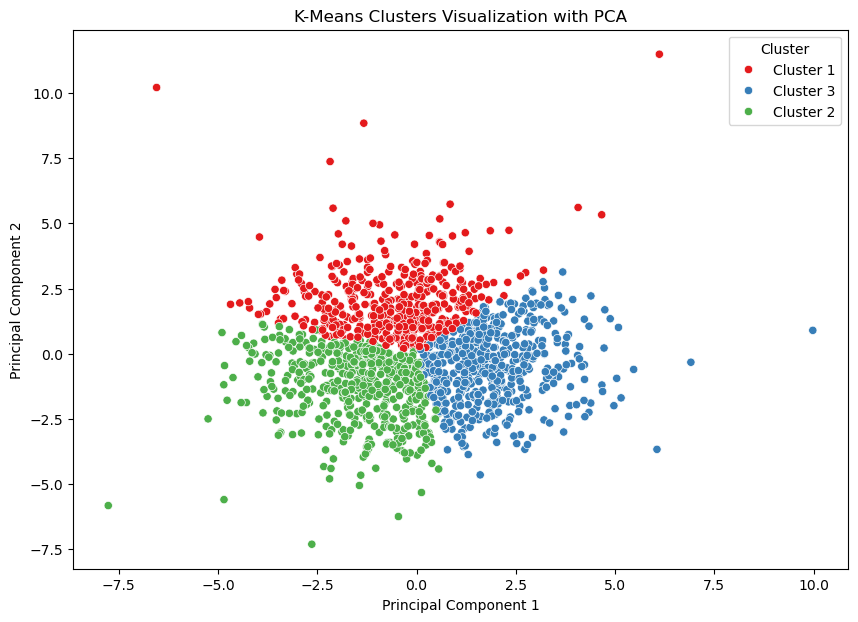

In [199]:
from sklearn.decomposition import PCA

# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for visualization
visualization_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': clustering_data['Cluster']
})

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(data=visualization_df, x='PC1', y='PC2', hue='Cluster', palette='Set1')
plt.title('K-Means Clusters Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


PCA: Reduces the dimensionality of the data to 2D for plotting.

Visualization: Helps in understanding how clusters are separated

# Understanding the Clustering Context

Before proceeding, it's important to note:

Clustering Level: The clustering we performed was on match-level data, where each row represents a single match and includes features for

 both the home and away teams.

Clusters Assigned to Matches: The clusters are assigned to matches, not directly to teams.

Teams Appearing in Multiple Clusters: A single team can appear in multiple clusters across different matches, depending on their 

performance in each match.

 # Applying PCA for Dimensionality Reduction
 
PCA can help in understanding the main factors that explain the variance in your data.

Step 1: Fit PCA

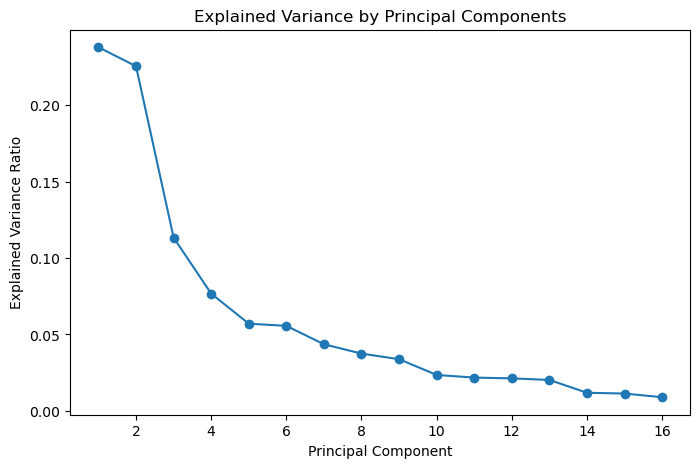

In [200]:
# Fit PCA to the scaled data
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Plot explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_, marker='o')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()


Choose Number of Components

Let's choose enough components to explain ~80% of the variance.

In [201]:
# Cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 80% variance
n_components = np.argmax(cumulative_variance >= 0.80) + 1
print(f'Number of components to explain 80% variance: {n_components}')


Number of components to explain 80% variance: 7


In [202]:
# Fit PCA with selected component
#  Fit PCA with n_components
pca_final = PCA(n_components=n_components)
X_pca_final = pca_final.fit_transform(X_scaled)


Interpret Principal Components

You can examine the loadings to understand what each principal component represents.

In [203]:
# Create a DataFrame of PCA components
pca_components = pd.DataFrame(pca_final.components_, columns=X.columns)
pca_components.index = [f'PC{i+1}' for i in range(n_components)]
print(pca_components)


     HomeTeam_GoalsFor_roll3  HomeTeam_GoalsAgainst_roll3  \
PC1                -0.183017                     0.240299   
PC2                 0.267601                    -0.232159   
PC3                 0.212143                     0.197789   
PC4                 0.272366                     0.183971   
PC5                -0.257737                     0.234271   
PC6                -0.388634                     0.389483   
PC7                 0.316184                     0.467023   

     HomeTeam_ShotsFor_roll3  HomeTeam_ShotsAgainst_roll3  \
PC1                -0.219815                     0.245547   
PC2                 0.275226                    -0.271326   
PC3                 0.366135                     0.344037   
PC4                 0.227712                     0.266370   
PC5                 0.089213                    -0.024875   
PC6                 0.161087                    -0.079669   
PC7                -0.227943                    -0.278103   

     HomeTeam_ShotsOnT

# clustering with respect to teams

# Match-Level Analysis

Step 1: Add Cluster Labels to the Original Data

Ensure that the cluster labels are merged back into the original merged_data_copy DataFrame.

In [204]:
# Ensure 'Cluster' labels are in the original data
merged_data_copy = merged_data_copy.loc[clustering_data.index]
merged_data_copy['Cluster'] = clustering_data['Cluster']


Step 2: Extract Teams per Cluster

In [205]:
# Group matches by 'Cluster'
cluster_groups = merged_data_copy.groupby('Cluster')


Step 3: List Teams in Each Cluster

We'll create a dictionary to store teams in each cluster.

In [206]:
# Initialize a dictionary to hold teams per cluster
teams_in_clusters = {}

for cluster, group in cluster_groups:
    # Extract home and away teams
    teams = pd.concat([group['HomeTeam'], group['AwayTeam']])
    
    # Get unique teams
    unique_teams = teams.unique()
    
    # Store in the dictionary
    teams_in_clusters[cluster] = unique_teams


In [207]:
# Print the teams present in each cluster
for cluster, teams in teams_in_clusters.items():
    print(f"\nTeams in {cluster}:")
    for team in teams:
        print(f"- {team}")



Teams in Cluster 1:
- Club Brugge
- Standard
- Mechelen
- Antwerp
- Gent
- Charleroi
- Genk
- Mouscron
- Kortrijk
- Anderlecht
- Waregem
- Cercle Brugge
- St Truiden
- Beerschot VA
- Oostende
- Eupen
- Waasland-Beveren
- St. Gilloise
- Oud-Heverlee Leuven
- Westerlo
- Seraing
- RWD Molenbeek

Teams in Cluster 2:
- Mouscron
- Anderlecht
- Oostende
- St Truiden
- Charleroi
- Kortrijk
- Genk
- Waregem
- Cercle Brugge
- Mechelen
- Club Brugge
- Antwerp
- Eupen
- Gent
- Standard
- Waasland-Beveren
- Beerschot VA
- Oud-Heverlee Leuven
- Seraing
- St. Gilloise
- Westerlo
- RWD Molenbeek

Teams in Cluster 3:
- Kortrijk
- Oostende
- Gent
- Cercle Brugge
- Eupen
- Genk
- Mechelen
- Waasland-Beveren
- Waregem
- St Truiden
- Mouscron
- Anderlecht
- Charleroi
- Antwerp
- Standard
- Oud-Heverlee Leuven
- Beerschot VA
- Seraing
- Club Brugge
- Westerlo
- RWD Molenbeek
- St. Gilloise


We loop through each cluster and collect all home and away teams involved in matches assigned to that cluster.

We then find the unique teams and print them.

Step 5: Count Team Appearances in Each Cluster (Optional)

If you want to see how many times each team appears in each cluster:

Step 4: Print Teams in Each Cluster

In [208]:
# Initialize a dictionary to hold team counts per cluster
team_counts_per_cluster = {}

for cluster, group in cluster_groups:
    # Extract home and away teams
    teams = pd.concat([group['HomeTeam'], group['AwayTeam']])
    
    # Count appearances
    team_counts = teams.value_counts()
    
    # Store in the dictionary
    team_counts_per_cluster[cluster] = team_counts

# Print team counts in each cluster
for cluster, counts in team_counts_per_cluster.items():
    print(f"\nTeam appearances in {cluster}:")
    print(counts)



Team appearances in Cluster 1:
Club Brugge            71
Gent                   65
Genk                   63
Antwerp                59
Anderlecht             57
Charleroi              56
Standard               54
Mechelen               51
Cercle Brugge          50
Kortrijk               50
St Truiden             44
St. Gilloise           41
Eupen                  40
Oud-Heverlee Leuven    35
Oostende               34
Waregem                28
Waasland-Beveren       19
Westerlo               19
Beerschot VA           17
Seraing                14
Mouscron               13
RWD Molenbeek           6
Name: count, dtype: int64

Team appearances in Cluster 2:
Club Brugge            91
Gent                   87
Anderlecht             84
Genk                   79
Standard               68
Antwerp                65
Cercle Brugge          64
St. Gilloise           63
St Truiden             55
Mechelen               50
Charleroi              43
Kortrijk               37
Oud-Heverlee Leuven    33


We count how many times each team appears in matches assigned to a cluster.

This can help identify which teams are more frequently associated with a cluster.


# 2. Determining the Predominant Cluster per Team

To assign each team to the cluster in which it appears most frequently:

Step 1: Initialize a DataFrame to Hold Counts

In [209]:
# Create a DataFrame to hold counts
team_cluster_counts = pd.DataFrame()

# Loop through each cluster and count team appearances
for cluster, group in cluster_groups:
    # Extract home and away teams
    teams = pd.concat([group['HomeTeam'], group['AwayTeam']])
    
    # Count appearances
    counts = teams.value_counts().reset_index()
    counts.columns = ['Team', 'Count']
    counts['Cluster'] = cluster
    
    # Append to the DataFrame
    team_cluster_counts = pd.concat([team_cluster_counts, counts], ignore_index=True)


Step 2: Pivot the Data to Have Clusters as Columns

In [210]:
# Pivot the DataFrame
team_cluster_pivot = team_cluster_counts.pivot_table(
    index='Team',
    columns='Cluster',
    values='Count',
    fill_value=0
)

# Reset index
team_cluster_pivot = team_cluster_pivot.reset_index()


Step 3: Determine the Predominant Cluster for Each Team

In [211]:
# Determine the cluster with the highest count for each team
team_cluster_pivot['Predominant_Cluster'] = team_cluster_pivot.iloc[:, 1:].idxmax(axis=1)


Step 4: Print the Predominant Cluster for Each Team

In [212]:
# Print the teams and their predominant clusters
print("\nTeams and their predominant clusters:")
for index, row in team_cluster_pivot.iterrows():
    print(f"- {row['Team']}: {row['Predominant_Cluster']}")



Teams and their predominant clusters:
- Anderlecht: Cluster 2
- Antwerp: Cluster 2
- Beerschot VA: Cluster 3
- Cercle Brugge: Cluster 2
- Charleroi: Cluster 3
- Club Brugge: Cluster 2
- Eupen: Cluster 3
- Genk: Cluster 2
- Gent: Cluster 2
- Kortrijk: Cluster 3
- Mechelen: Cluster 3
- Mouscron: Cluster 3
- Oostende: Cluster 3
- Oud-Heverlee Leuven: Cluster 3
- RWD Molenbeek: Cluster 3
- Seraing: Cluster 3
- St Truiden: Cluster 3
- St. Gilloise: Cluster 2
- Standard: Cluster 2
- Waasland-Beveren: Cluster 3
- Waregem: Cluster 3
- Westerlo: Cluster 3


We pivot the data to have clusters as columns and counts as values.
We then identify the cluster with the highest count for each team.
This assigns each team to a single cluster based on where they appear most frequently.


##  THI IS NOT PART OF THE THESIS WORK

# Alternative: Clustering Teams Directly

If you prefer to cluster teams directly, assigning each team to a single cluster, you can aggregate the data to have one row per team.

Step 1: Aggregate Rolling Averages per Team

In [213]:
# Prepare team-level data
team_features = team_stats.copy()

# Remove matches with missing rolling averages
team_features.dropna(subset=numerical_vars, inplace=True)

# Aggregate by team
team_aggregated = team_features.groupby('Team')[numerical_vars].mean().reset_index()


We compute the average of the rolling averages for each team.

This gives us a team-level dataset suitable for clustering.

Step 2: Standardize the Features

In [214]:
# Features matrix
X_team = team_aggregated[numerical_vars]

# Standardize the features
X_team_scaled = scaler.fit_transform(X_team)


Step 3: Apply Clustering Algorithm

We'll use K-Means .

In [215]:
# Fit K-Means with k=3
kmeans_team = KMeans(n_clusters=3, random_state=42)
kmeans_team_labels = kmeans_team.fit_predict(X_team_scaled)

# Add cluster labels to the data
team_aggregated['Cluster'] = kmeans_team_labels

# Map cluster numbers to meaningful names (optional)
cluster_mapping = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'}
team_aggregated['Cluster'] = team_aggregated['Cluster'].map(cluster_mapping)


Step 4: Print Teams in Each Cluster

In [216]:
# Group teams by cluster
team_cluster_groups = team_aggregated.groupby('Cluster')

# Print teams in each cluster
for cluster, group in team_cluster_groups:
    print(f"\nTeams in {cluster}:")
    for team in group['Team']:
        print(f"- {team}")



Teams in Cluster 1:
- Anderlecht
- Antwerp
- Club Brugge
- Genk
- Gent
- St. Gilloise

Teams in Cluster 2:
- RWD Molenbeek
- Seraing
- Waasland-Beveren
- Waregem

Teams in Cluster 3:
- Beerschot VA
- Cercle Brugge
- Charleroi
- Eupen
- Kortrijk
- Mechelen
- Mouscron
- Oostende
- Oud-Heverlee Leuven
- St Truiden
- Standard
- Westerlo


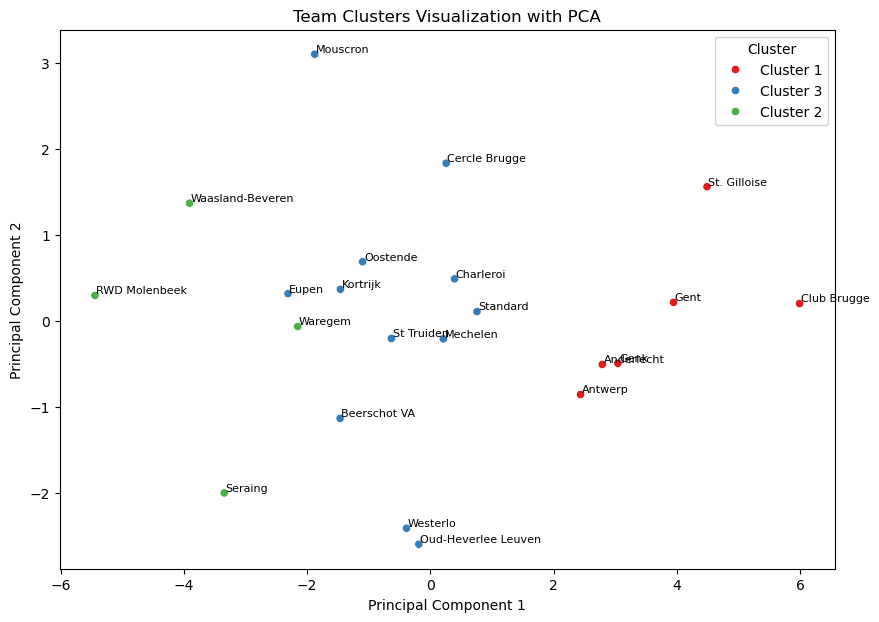

In [217]:
# Reduce dimensions for visualization
X_team_pca = pca.fit_transform(X_team_scaled)

# Create a DataFrame for visualization
team_visualization_df = pd.DataFrame({
    'PC1': X_team_pca[:, 0],
    'PC2': X_team_pca[:, 1],
    'Cluster': team_aggregated['Cluster'],
    'Team': team_aggregated['Team']
})

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(data=team_visualization_df, x='PC1', y='PC2', hue='Cluster', palette='Set1')
plt.title('Team Clusters Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Annotate points with team names
for i in range(team_visualization_df.shape[0]):
    plt.text(
        x=team_visualization_df['PC1'][i]+0.02,
        y=team_visualization_df['PC2'][i]+0.02,
        s=team_visualization_df['Team'][i],
        fontdict=dict(color='black', size=8),
    )

plt.show()


Now, each team is assigned to a single cluster based on their aggregated performance metrics.

We can directly list the teams in each cluster.

# Option 1: Match-Level Clustering

Teams in Each Cluster:

Teams can appear in multiple clusters since the clustering is based on matches.

We can list teams per cluster and count their appearances.

Predominant Cluster per Team:

By counting the number of times a team appears in each cluster, we can assign a predominant cluster to each team.

# Directly Clustering Teams:

Aggregating performance metrics per team allows us to assign each team to a single cluster.

This method may be more meaningful if you want to categorize teams based on overall performance.

##  THESIS CONTINUES

#  HEAT MAP OF TEAMS COUNT IN THE DIFFERENT  MATCH CLUSTERS

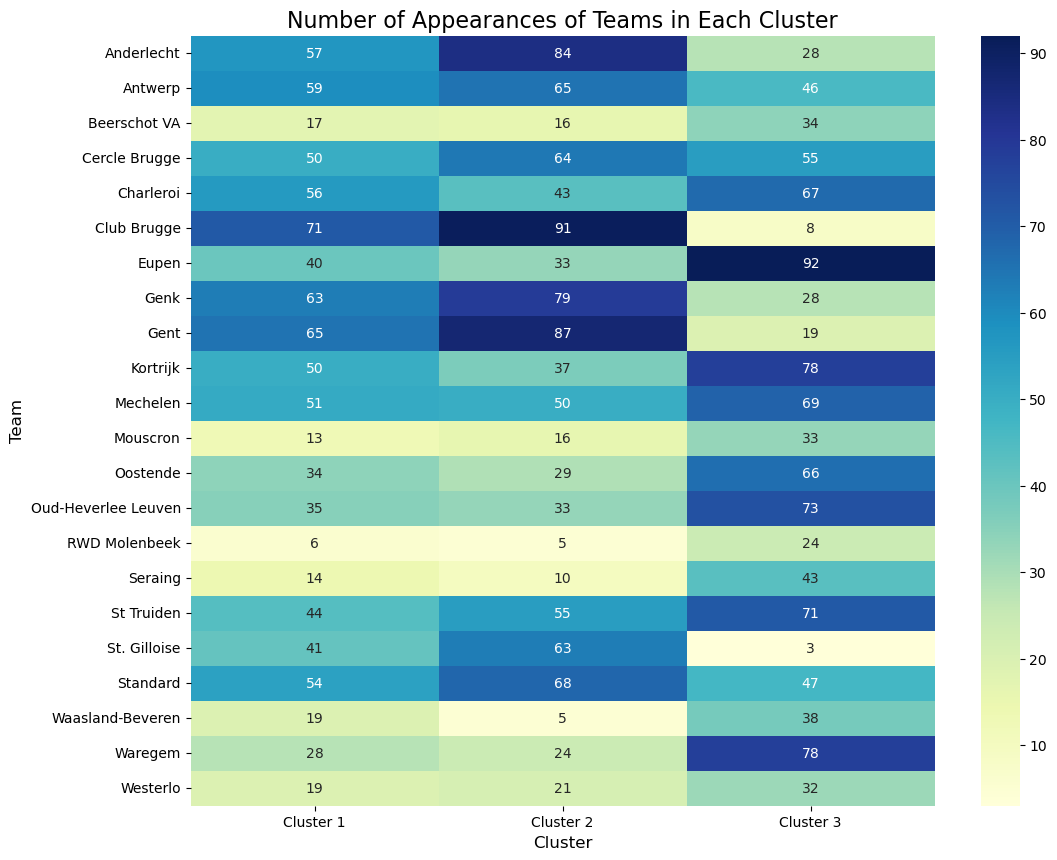

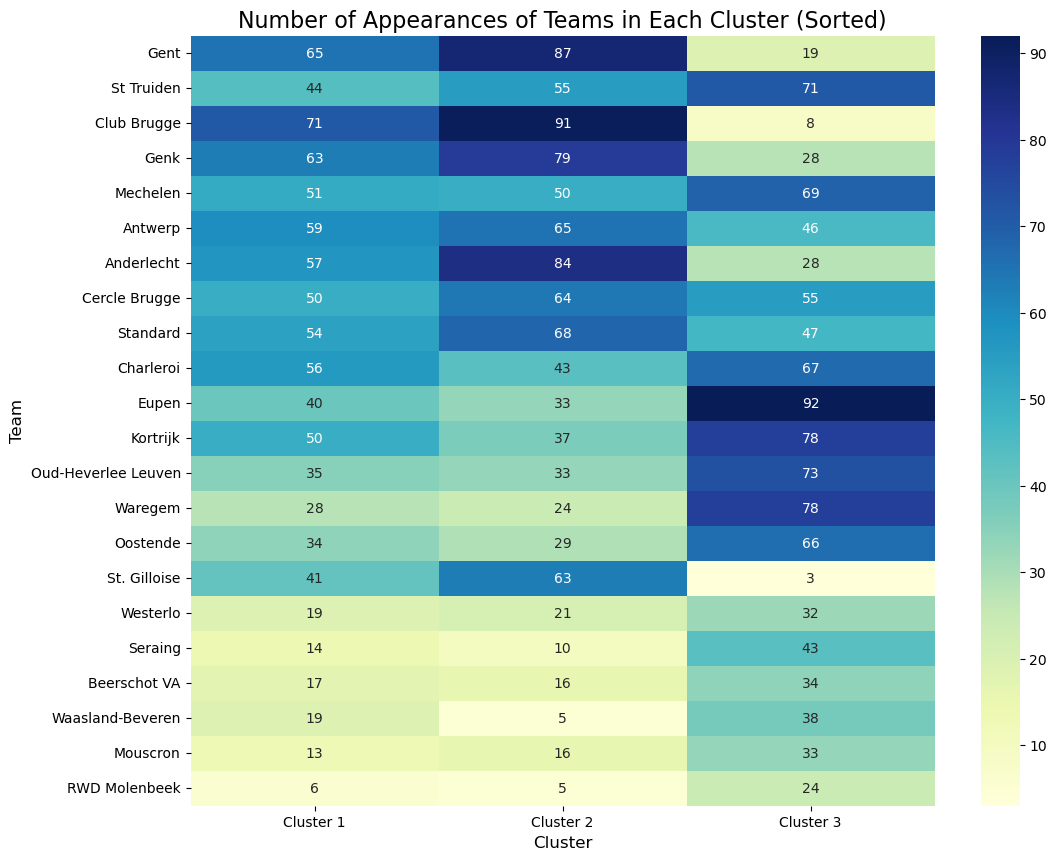

In [218]:
# 1. Ensure Cluster Labels are in the Original Data
merged_data_copy = merged_data_copy.loc[clustering_data.index]
merged_data_copy['Cluster'] = clustering_data['Cluster']

# 2. Melt the Data to Count Team Appearances per Cluster
home_team_clusters = merged_data_copy[['HomeTeam', 'Cluster']].rename(columns={'HomeTeam': 'Team'})
away_team_clusters = merged_data_copy[['AwayTeam', 'Cluster']].rename(columns={'AwayTeam': 'Team'})
team_clusters = pd.concat([home_team_clusters, away_team_clusters], ignore_index=True)

# 3. Create a Pivot Table
team_cluster_counts = team_clusters.groupby(['Team', 'Cluster']).size().reset_index(name='Count')
team_cluster_pivot = team_cluster_counts.pivot_table(
    index='Team',
    columns='Cluster',
    values='Count',
    fill_value=0
)

# 4. Optional: Normalize Counts to Percentages
team_totals = team_cluster_pivot.sum(axis=1)
team_cluster_percentages = team_cluster_pivot.div(team_totals, axis=0) * 100

# 5. Create the Heatmap of Counts
plt.figure(figsize=(12, 10))
sns.heatmap(
    team_cluster_pivot,
    annot=True,
   
    cmap='YlGnBu'
)
plt.title('Number of Appearances of Teams in Each Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.show()

# Sort teams by total appearances descending
team_cluster_pivot_sorted = team_cluster_pivot.loc[team_totals.sort_values(ascending=False).index]

# Create the heatmap with sorted teams
plt.figure(figsize=(12, 10))
sns.heatmap(
    team_cluster_pivot_sorted,
    annot=True,
  
    cmap='YlGnBu'
)
plt.title('Number of Appearances of Teams in Each Cluster (Sorted)', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.show()

In [219]:
print(merged_data_copy.columns)


Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS',
       'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR',
       'B365H', 'B365D', 'B365A', 'Hour', 'FTR_numeric', 'Year', 'Month',
       'Day', 'HomeTeam_enc', 'AwayTeam_enc', 'DayOfWeek_Num', 'MatchID',
       'HomeTeam_GoalsFor_roll3', 'HomeTeam_GoalsAgainst_roll3',
       'HomeTeam_ShotsFor_roll3', 'HomeTeam_ShotsOnTargetFor_roll3',
       'HomeTeam_FoulsFor_roll3', 'HomeTeam_CornersFor_roll3',
       'HomeTeam_YellowCardsFor_roll3', 'HomeTeam_RedCardsFor_roll3',
       'HomeTeam_ShotsAgainst_roll3', 'HomeTeam_ShotsOnTargetAgainst_roll3',
       'HomeTeam_FoulsAgainst_roll3', 'HomeTeam_CornersAgainst_roll3',
       'HomeTeam_YellowCardsAgainst_roll3', 'HomeTeam_RedCardsAgainst_roll3',
       'AwayTeam_GoalsFor_roll3', 'AwayTeam_GoalsAgainst_roll3',
       'AwayTeam_ShotsFor_roll3', 'AwayTeam_ShotsOnTargetFor_roll3',
       'AwayTeam_FoulsFor_roll3', 'AwayTeam_CornersFor_roll3',
       'Away

##  Machine leanrning models.

# Data Preparation

 Copy the Data and Remove Leakage Features

In [220]:
# Copy the data
data = merged_data_copy.copy()

# Remove leakage features
leakage_features = ['Div',
 'HomeTeam',
 'AwayTeam',
 'Hour',
    'Date', 'MatchID', 'FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST',
    'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR','Result',
    'FTR', 'FTR_numeric', 'FTR_category'  # Include target and its variants
]



# Exclude leakage features
features = [col for col in data.columns if col not in leakage_features]

print(f"Number of features after removing leakage features: {len(features)}")


Number of features after removing leakage features: 38


In [221]:
# Identify numerical features (since we have no categorical features now)
numerical_features = features  # All remaining features are numerical

print("Numerical features:", numerical_features)


Numerical features: ['B365H', 'B365D', 'B365A', 'Year', 'Month', 'Day', 'HomeTeam_enc', 'AwayTeam_enc', 'DayOfWeek_Num', 'HomeTeam_GoalsFor_roll3', 'HomeTeam_GoalsAgainst_roll3', 'HomeTeam_ShotsFor_roll3', 'HomeTeam_ShotsOnTargetFor_roll3', 'HomeTeam_FoulsFor_roll3', 'HomeTeam_CornersFor_roll3', 'HomeTeam_YellowCardsFor_roll3', 'HomeTeam_RedCardsFor_roll3', 'HomeTeam_ShotsAgainst_roll3', 'HomeTeam_ShotsOnTargetAgainst_roll3', 'HomeTeam_FoulsAgainst_roll3', 'HomeTeam_CornersAgainst_roll3', 'HomeTeam_YellowCardsAgainst_roll3', 'HomeTeam_RedCardsAgainst_roll3', 'AwayTeam_GoalsFor_roll3', 'AwayTeam_GoalsAgainst_roll3', 'AwayTeam_ShotsFor_roll3', 'AwayTeam_ShotsOnTargetFor_roll3', 'AwayTeam_FoulsFor_roll3', 'AwayTeam_CornersFor_roll3', 'AwayTeam_YellowCardsFor_roll3', 'AwayTeam_RedCardsFor_roll3', 'AwayTeam_ShotsAgainst_roll3', 'AwayTeam_ShotsOnTargetAgainst_roll3', 'AwayTeam_FoulsAgainst_roll3', 'AwayTeam_CornersAgainst_roll3', 'AwayTeam_YellowCardsAgainst_roll3', 'AwayTeam_RedCardsAgainst

In [222]:
# Reset index to ensure indices are consecutive
data.reset_index(drop=True, inplace=True)


In [223]:
data['FTR_category'].head(10)

KeyError: 'FTR_category'

In [ ]:
print("Unique values in 'FTR_category':")
print(data['FTR_category'].unique())


Unique values in 'FTR_category':
['Home Win', 'Draw', 'Away Win']
Categories (3, object): ['Away Win', 'Draw', 'Home Win']


In [ ]:
target_mapping = {'Home Win': 1, 'Draw': 0, 'Away Win': 2}


In [ ]:
data['FTR_encoded'] = data['FTR_category'].map(target_mapping)


In [ ]:
print("Target variable value counts:")
print(data['FTR_encoded'].value_counts())


Target variable value counts:
FTR_encoded
1    634
2    478
0    336
Name: count, dtype: int64


# Handling missing data

In [ ]:
# Reset index to ensure indices are consecutive
data.reset_index(drop=True, inplace=True)

In [ ]:
# Map 'Cluster' to numeric values if appropriate
cluster_mapping = {'Cluster 1': 1, 'Cluster 2': 2, 'Cluster 3': 3}
data['Cluster'] = data['Cluster'].map(cluster_mapping)

# Update feature lists
categorical_features = []
numerical_features = [col for col in features if col != 'Cluster'] + ['Cluster']


In [ ]:
# Define the target variable
target = 'FTR_encoded'


In [ ]:
# Remove 'FTR_encoded' from features if present
features = [col for col in data.columns if col not in leakage_features + [target]]


In [ ]:
data.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,AwayTeam_YellowCardsFor_roll3,AwayTeam_RedCardsFor_roll3,AwayTeam_ShotsAgainst_roll3,AwayTeam_ShotsOnTargetAgainst_roll3,AwayTeam_FoulsAgainst_roll3,AwayTeam_CornersAgainst_roll3,AwayTeam_YellowCardsAgainst_roll3,AwayTeam_RedCardsAgainst_roll3,Cluster,FTR_encoded
0,B1,2019-08-02,Club Brugge,St Truiden,6,0,H,16.0,4.0,10.0,...,2.0,0.0,10.0,6.0,21.0,5.0,4.0,0.0,1,1
1,B1,2019-08-03,Standard,Waregem,4,0,H,16.0,3.0,7.0,...,3.0,0.0,10.0,5.0,21.0,2.0,1.0,0.0,1,1
2,B1,2019-08-03,Kortrijk,Charleroi,1,1,D,7.0,11.0,4.0,...,0.0,0.0,5.0,4.0,21.0,6.0,2.0,0.0,3,0
3,B1,2019-08-03,Oostende,Cercle Brugge,3,1,H,11.0,9.0,7.0,...,2.0,1.0,14.0,9.0,15.0,7.0,2.0,0.0,3,1
4,B1,2019-08-03,Mechelen,Genk,3,1,H,11.0,9.0,5.0,...,0.0,0.0,8.0,4.0,22.0,2.0,1.0,0.0,1,1


Encode Target Variable

# Split Data 

4 seasons for  training and the 2023/2024 season for testing

In [ ]:
# Import necessary library
import pandas as pd
from sklearn.model_selection import train_test_split

# Convert Year, Month, and Day columns into a single datetime column
data['Date'] = pd.to_datetime(data[['Year', 'Month', 'Day']])

# Define the cutoff date for splitting
cutoff_date = pd.Timestamp('2023-07-28')

# Split the data into training and test sets based on the cutoff date
train_data = data[data['Date'] < cutoff_date]
test_data = data[data['Date'] >= cutoff_date]

# Separate features and target for training and test sets
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Verify the shapes of the resulting datasets
print(f"Total training samples: {X_train.shape[0]}")
print(f"Total testing samples: {X_test.shape[0]}")


Total training samples: 1137
Total testing samples: 311


In [ ]:
test_data.tail()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,AwayTeam_YellowCardsFor_roll3,AwayTeam_RedCardsFor_roll3,AwayTeam_ShotsAgainst_roll3,AwayTeam_ShotsOnTargetAgainst_roll3,AwayTeam_FoulsAgainst_roll3,AwayTeam_CornersAgainst_roll3,AwayTeam_YellowCardsAgainst_roll3,AwayTeam_RedCardsAgainst_roll3,Cluster,FTR_encoded
1443,B1,2024-05-25,Oud-Heverlee Leuven,Westerlo,1,2,A,10.0,21.0,3.0,...,1.6,0.0,15.4,6.4,11.2,4.6,1.8,0.0,2,2
1444,B1,2024-05-26,Antwerp,Anderlecht,3,1,H,21.0,15.0,5.0,...,1.0,0.0,15.4,4.2,11.4,4.2,2.8,0.0,3,1
1445,B1,2024-05-26,Club Brugge,Cercle Brugge,0,0,D,10.0,7.0,3.0,...,2.2,0.0,12.8,5.0,11.6,3.8,1.8,0.0,1,0
1446,B1,2024-05-26,St. Gilloise,Genk,2,0,H,21.0,9.0,8.0,...,2.0,0.0,15.0,5.4,11.2,3.8,1.0,0.0,1,1
1447,B1,2024-06-02,Genk,Gent,0,1,A,10.0,13.0,4.0,...,0.8,0.0,14.0,4.6,11.6,5.2,1.8,0.0,3,2


Combine Splits from All Years

In [ ]:
print(X_train.dtypes)

B365H                                  float64
B365D                                  float64
B365A                                  float64
Year                                     int32
Month                                    int32
Day                                      int32
HomeTeam_enc                             int32
AwayTeam_enc                             int32
DayOfWeek_Num                            int64
HomeTeam_GoalsFor_roll3                float64
HomeTeam_GoalsAgainst_roll3            float64
HomeTeam_ShotsFor_roll3                float64
HomeTeam_ShotsOnTargetFor_roll3        float64
HomeTeam_FoulsFor_roll3                float64
HomeTeam_CornersFor_roll3              float64
HomeTeam_YellowCardsFor_roll3          float64
HomeTeam_RedCardsFor_roll3             float64
HomeTeam_ShotsAgainst_roll3            float64
HomeTeam_ShotsOnTargetAgainst_roll3    float64
HomeTeam_FoulsAgainst_roll3            float64
HomeTeam_CornersAgainst_roll3          float64
HomeTeam_Yell

Check Target Distribution

In [ ]:
# Check target distribution in training set
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

# Check target distribution in testing set
print("Testing target distribution:")
print(y_test.value_counts(normalize=True))


Training target distribution:
FTR_encoded
1    0.435356
2    0.340369
0    0.224274
Name: proportion, dtype: float64
Testing target distribution:
FTR_encoded
1    0.446945
2    0.292605
0    0.260450
Name: proportion, dtype: float64


Build Preprocessing Pipeline

Since we have only numerical features, create a pipeline for numerical data.

In [ ]:
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, features)
])


# Model Building and Hyperparameter Tuning

3.1. Define Models and Parameter Grids

In [ ]:
# Logistic Regression
model_lr = LogisticRegression(solver='saga',max_iter=1000)
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],  # Regularization strength
    'model__penalty': ['elasticnet'],  # Use elastic net regularization
    'model__l1_ratio': [0.1, 0.5, 0.7, 0.9]  # Ratio of L1 vs L2 regularization
}

# Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'model__max_depth': [None, 5, 10,15,20,25],
    'model__min_samples_split': [2, 5,10]
}

# Random Forest
model_rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'model__n_estimators': [50,100,150, 200,250,300],
    'model__max_depth': [None, 5, 10,20],
    'model__min_samples_split': [2, 5,10]
}

# Support Vector Machine
model_svc = SVC(random_state=42, probability=True)
param_grid_svc = {
    'model__C': [0.1, 1, 10,100],
    'model__kernel': ['linear', 'rbf']
}

# XGBoost
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
param_grid_xgb = {
    'model__n_estimators': [50,100,150, 200,250,300],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5]
}

# K-Nearest Neighbors
model_knn = KNeighborsClassifier()
param_grid_knn = {
    'model__n_neighbors': [5, 10,15,20],
    'model__weights': ['uniform', 'distance']
}

# Naive Bayes
model_nb = GaussianNB()
param_grid_nb = {}  # No hyperparameters to tune

# List of models
models = [
    ('Logistic Regression', model_lr, param_grid_lr),
    ('Decision Tree', model_dt, param_grid_dt),
    ('Random Forest', model_rf, param_grid_rf),
    ('Support Vector Machine', model_svc, param_grid_svc),
    ('XGBoost', model_xgb, param_grid_xgb),
    ('K-Nearest Neighbors', model_knn, param_grid_knn),
    ('Naive Bayes', model_nb, param_grid_nb)
]

# Neural Network (MLP)
from sklearn.neural_network import MLPClassifier

# Define the neural network model
model_nn = MLPClassifier(max_iter=1000, random_state=42)
param_grid_nn = {
    'model__hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'model__activation': ['relu', 'tanh'],
    'model__solver': ['adam', 'sgd'],
    'model__learning_rate_init': [0.001, 0.01],
    'model__alpha': [0.0001, 0.001]  # L2 regularization
}

# Add neural network to the models list
models.append(('Neural Network', model_nn, param_grid_nn))


3.2. Training and Evaluating Models

In [ ]:
# Prepare for model training and evaluation
results = []

# Training and evaluation
for name, model, param_grid in models:
    print(f"\nTraining {name}...")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Use 'f1_weighted' as scoring metric
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_estimator = grid_search.best_estimator_
        best_params = grid_search.best_params_
    else:
        best_estimator = pipeline.fit(X_train, y_train)
        best_params = {}
    
    y_pred = best_estimator.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Best Parameters': best_params,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
    
    # Define target names
    target_names = ['Draw (0)', 'Home Win (1)', 'Away Win (2)']
    
    print(f"Best Parameters for {name}: {best_params}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

# Display the results in tabular form
results_df = pd.DataFrame(results)
print("\nSummary of Results:")
print(results_df)

# Optionally, save results to a file
results_df.to_csv('model_results.csv', index=False)


Training Logistic Regression...
Best Parameters for Logistic Regression: {'model__C': 0.1, 'model__l1_ratio': 0.7, 'model__penalty': 'elasticnet'}
Accuracy: 0.5209
Precision: 0.4470, Recall: 0.5209, F1 Score: 0.4526
              precision    recall  f1-score   support

    Draw (0)       0.20      0.01      0.02        81
Home Win (1)       0.59      0.71      0.64       139
Away Win (2)       0.45      0.69      0.55        91

    accuracy                           0.52       311
   macro avg       0.41      0.47      0.40       311
weighted avg       0.45      0.52      0.45       311


Training Decision Tree...
Best Parameters for Decision Tree: {'model__max_depth': 5, 'model__min_samples_split': 10}
Accuracy: 0.4727
Precision: 0.4599, Recall: 0.4727, F1 Score: 0.4639
              precision    recall  f1-score   support

    Draw (0)       0.31      0.23      0.27        81
Home Win (1)       0.52      0.59      0.55       139
Away Win (2)       0.51      0.51      0.51        9

In [ ]:
# Prepare for model training and evaluation
results = []

# Training and evaluation
for name, model, param_grid in models:
    print(f"\nTraining {name}...")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Use 'f1_weighted' as scoring metric
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_estimator = grid_search.best_estimator_
        best_params = grid_search.best_params_
    else:
        best_estimator = pipeline.fit(X_train, y_train)
        best_params = {}
    
    y_pred = best_estimator.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Best Parameters': best_params,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
    
    # Define target names
    target_names = ['Draw (0)', 'Home Win (1)', 'Away Win (2)']
    
    print(f"Best Parameters for {name}: {best_params}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

# Display the results in tabular form
results_df = pd.DataFrame(results)
print("\nSummary of Results:")
print(results_df)

# Optionally, save results to a file
results_df.to_csv('model_results.csv', index=False)


Training Logistic Regression...
Best Parameters for Logistic Regression: {'model__C': 0.1, 'model__l1_ratio': 0.7, 'model__penalty': 'elasticnet'}
Accuracy: 0.5209
Precision: 0.4470, Recall: 0.5209, F1 Score: 0.4526
              precision    recall  f1-score   support

    Draw (0)       0.20      0.01      0.02        81
Home Win (1)       0.59      0.71      0.64       139
Away Win (2)       0.45      0.69      0.55        91

    accuracy                           0.52       311
   macro avg       0.41      0.47      0.40       311
weighted avg       0.45      0.52      0.45       311


Training Decision Tree...
Best Parameters for Decision Tree: {'model__max_depth': 5, 'model__min_samples_split': 10}
Accuracy: 0.4727
Precision: 0.4599, Recall: 0.4727, F1 Score: 0.4639
              precision    recall  f1-score   support

    Draw (0)       0.31      0.23      0.27        81
Home Win (1)       0.52      0.59      0.55       139
Away Win (2)       0.51      0.51      0.51        9

In [ ]:
# Prepare for model training and evaluation
results = []

# Training and evaluation
for name, model, param_grid in models:
    print(f"\nTraining {name}...")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Use 'f1_weighted' as scoring metric
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_estimator = grid_search.best_estimator_
        best_params = grid_search.best_params_
    else:
        best_estimator = pipeline.fit(X_train, y_train)
        best_params = {}
    
    y_pred = best_estimator.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Best Parameters': best_params,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
    
    # Define target names
    target_names = ['Draw (0)', 'Home Win (1)', 'Away Win (2)']
    
    print(f"Best Parameters for {name}: {best_params}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

# Display the results in tabular form
results_df = pd.DataFrame(results)
print("\nSummary of Results:")
print(results_df)

# Optionally, save results to a file
results_df.to_csv('model_results.csv', index=False)


Training Logistic Regression...
Best Parameters for Logistic Regression: {'model__C': 0.1, 'model__l1_ratio': 0.7, 'model__penalty': 'elasticnet'}
Accuracy: 0.5209
Precision: 0.4470, Recall: 0.5209, F1 Score: 0.4526
              precision    recall  f1-score   support

    Draw (0)       0.20      0.01      0.02        81
Home Win (1)       0.59      0.71      0.64       139
Away Win (2)       0.45      0.69      0.55        91

    accuracy                           0.52       311
   macro avg       0.41      0.47      0.40       311
weighted avg       0.45      0.52      0.45       311


Training Decision Tree...
Best Parameters for Decision Tree: {'model__max_depth': 5, 'model__min_samples_split': 10}
Accuracy: 0.4727
Precision: 0.4599, Recall: 0.4727, F1 Score: 0.4639
              precision    recall  f1-score   support

    Draw (0)       0.31      0.23      0.27        81
Home Win (1)       0.52      0.59      0.55       139
Away Win (2)       0.51      0.51      0.51        9

4. Displaying All Model Results

In [ ]:
# Create a DataFrame from results
results_df = pd.DataFrame(results)

# Sort the results by F1 Score
results_df.sort_values(by='F1 Score', ascending=False, inplace=True)

# Display the results
print("\nModel Comparison:")
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Best Parameters']].head(8))



Model Comparison:
                    Model  Accuracy  Precision    Recall  F1 Score  \
2           Random Forest  0.533762   0.509732  0.533762  0.481707   
5     K-Nearest Neighbors  0.498392   0.465907  0.498392  0.467548   
1           Decision Tree  0.472669   0.459869  0.472669  0.463908   
0     Logistic Regression  0.520900   0.446989  0.520900  0.452632   
3  Support Vector Machine  0.520900   0.440947  0.520900  0.450169   
4                 XGBoost  0.511254   0.443604  0.511254  0.444820   
7          Neural Network  0.475884   0.445689  0.475884  0.444217   
6             Naive Bayes  0.469453   0.454053  0.469453  0.440675   

                                     Best Parameters  
2  {'model__max_depth': None, 'model__min_samples...  
5  {'model__n_neighbors': 10, 'model__weights': '...  
1  {'model__max_depth': 5, 'model__min_samples_sp...  
0  {'model__C': 0.1, 'model__l1_ratio': 0.7, 'mod...  
3            {'model__C': 1, 'model__kernel': 'rbf'}  
4  {'model__learning

Explanation
Splitting Data Within Each Year
Why Split Within Each Year?

To ensure that the test set contains data from all years, reflecting the same temporal distribution as the training set.
By taking 20% of the data from each year for testing, we prevent any year from being overrepresented or underrepresented in either set.
Stratification:

We use stratify=y_year in train_test_split to maintain the class distribution of the target variable within each year's split.
This helps in handling any class imbalance issues.
Combining Data:

After splitting within each year, we concatenate the training sets and testing sets from all years.
We reset the indices to avoid any issues with mismatched indices during training.
Ensuring No Data Leakage
Removing Leakage Features:

We remove features that are not available before the match or could leak future information.
This ensures that our models are trained on data that would realistically be available at prediction time.
Using F1 Score for Hyperparameter Tuning
Why F1 Score?

F1 Score balances precision and recall, providing a single metric that accounts for both false positives and false negatives.
Using 'f1_weighted' accounts for class imbalance by weighting the score by support (number of true instances for each class).
Including Naive Bayes Classifier
Naive Bayes:

A simple yet effective classifier, particularly suitable for high-dimensional data.
Doesn't have hyperparameters to tune, so we directly fit the model.
Conclusion
By following the updated instructions:

Data Splitting:

we Used the 2023/2024 season for model testing
We trained six classification models, including Naive Bayes, and used F1 Score for hyperparameter tuning.
Evaluation:

The models' performance metrics are displayed in a single table, allowing for easy comparison.
Next Steps:

Analyze the Results:

Identify which model performed the best based on F1 Score.
Investigate why certain models performed better than others.
Feature Importance:

For tree-based models, extract and analyze feature importances to understand which features contribute most to the predictions.
Model Improvement:

Consider ensemble methods or stacking models for potentially better performance.
Address any remaining class imbalance issues, perhaps by using techniques like SMOTE.


##  Feature importance

Models with Feature Importances:

Decision Tree

Random Forest

XGBoost

Models with Coefficients:

Logistic Regression

Models without Feature Importances:

Support Vector Machine

K-Nearest Neighbors

Naive Bayes

Preparing to Extract Feature Importances

1.1. Get Feature Names After Preprocessing

When using a Pipeline and ColumnTransformer, feature names can be transformed or expanded (e.g., after one-hot encoding). We'll need to 

extract the feature names after preprocessing to correctly map the importances.

In [ ]:
def get_feature_names(preprocessor):
    """
    Retrieve feature names from a ColumnTransformer.

    Parameters:
    - preprocessor: the ColumnTransformer used in the pipeline

    Returns:
    - feature_names: a list of feature names after preprocessing
    """
    feature_names = []

    # For numerical features
    if 'num' in preprocessor.named_transformers_:
        num_features = preprocessor.named_transformers_['num']['imputer'].feature_names_in_
        feature_names.extend(num_features)

    # For categorical features
    if 'cat' in preprocessor.named_transformers_:
        cat_transformer = preprocessor.named_transformers_['cat']
        cat_features = cat_transformer['onehot'].get_feature_names_out(categorical_features)
        feature_names.extend(cat_features)

    return feature_names


In [ ]:
def get_feature_names(preprocessor):
    return preprocessor.named_transformers_['num']['imputer'].feature_names_in_


In [ ]:
def plot_feature_importances(feature_names, importances, model_name):
    # Sort features by importance
    indices = np.argsort(importances)[::-1]
    sorted_features = [feature_names[i] for i in indices]
    sorted_importances = importances[indices]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.title(f'Feature Importances for {model_name}')
    plt.bar(range(len(importances)), sorted_importances, align='center')
    plt.xticks(range(len(importances)), sorted_features, rotation=90)
    plt.tight_layout()
    plt.show()


Extracting Feature Importances for Each Model

We'll iterate through the models and extract feature importances where possible.

Initialize a List to Store Feature Importances

In [ ]:
feature_importance_results = []


Iterate Over Trained Models

We need to access the best estimators from the grid search for models that support feature importances.

In [ ]:
# Training and evaluating models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

results = []

for name, model, param_grid in models:
    print(f"\nTraining {name}...")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Use 'f1_weighted' as scoring metric
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_estimator = grid_search.best_estimator_
        best_params = grid_search.best_params_
    else:
        best_estimator = pipeline.fit(X_train, y_train)
        best_params = {}
    
    y_pred = best_estimator.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Best Parameters': best_params,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Best Estimator': best_estimator  # Store the best estimator
    })
    
    # Convert class labels to strings for classification report
    target_names = ['Draw (0)', 'Home Win (1)', 'Away Win (2)']
    
    print(f"Best Parameters for {name}: {best_params}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))



Training Logistic Regression...
Best Parameters for Logistic Regression: {'model__C': 0.1, 'model__l1_ratio': 0.7, 'model__penalty': 'elasticnet'}
Accuracy: 0.5209
Precision: 0.4470, Recall: 0.5209, F1 Score: 0.4526
              precision    recall  f1-score   support

    Draw (0)       0.20      0.01      0.02        81
Home Win (1)       0.59      0.71      0.64       139
Away Win (2)       0.45      0.69      0.55        91

    accuracy                           0.52       311
   macro avg       0.41      0.47      0.40       311
weighted avg       0.45      0.52      0.45       311


Training Decision Tree...
Best Parameters for Decision Tree: {'model__max_depth': 5, 'model__min_samples_split': 10}
Accuracy: 0.4727
Precision: 0.4599, Recall: 0.4727, F1 Score: 0.4639
              precision    recall  f1-score   support

    Draw (0)       0.31      0.23      0.27        81
Home Win (1)       0.52      0.59      0.55       139
Away Win (2)       0.51      0.51      0.51        9

In [ ]:
# Create a DataFrame from results
results_df = pd.DataFrame(results)

# Sort the results by F1 Score
results_df.sort_values(by='F1 Score', ascending=False, inplace=True)

# Display the results
print("\nModel Comparison:")
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Best Parameters']].head(8))


Model Comparison:
                    Model  Accuracy  Precision    Recall  F1 Score  \
2           Random Forest  0.533762   0.509732  0.533762  0.481707   
5     K-Nearest Neighbors  0.498392   0.465907  0.498392  0.467548   
1           Decision Tree  0.472669   0.459869  0.472669  0.463908   
0     Logistic Regression  0.520900   0.446989  0.520900  0.452632   
3  Support Vector Machine  0.520900   0.440947  0.520900  0.450169   
4                 XGBoost  0.511254   0.443604  0.511254  0.444820   
7          Neural Network  0.475884   0.445689  0.475884  0.444217   
6             Naive Bayes  0.469453   0.454053  0.469453  0.440675   

                                     Best Parameters  
2  {'model__max_depth': None, 'model__min_samples...  
5  {'model__n_neighbors': 10, 'model__weights': '...  
1  {'model__max_depth': 5, 'model__min_samples_sp...  
0  {'model__C': 0.1, 'model__l1_ratio': 0.7, 'mod...  
3            {'model__C': 1, 'model__kernel': 'rbf'}  
4  {'model__learning


Processing Logistic Regression...


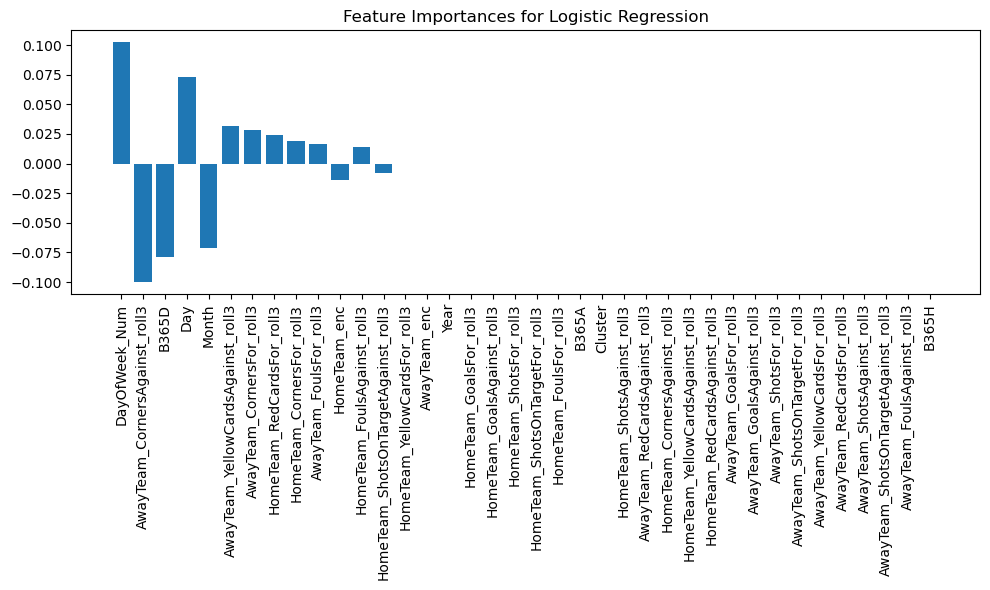


Processing Decision Tree...


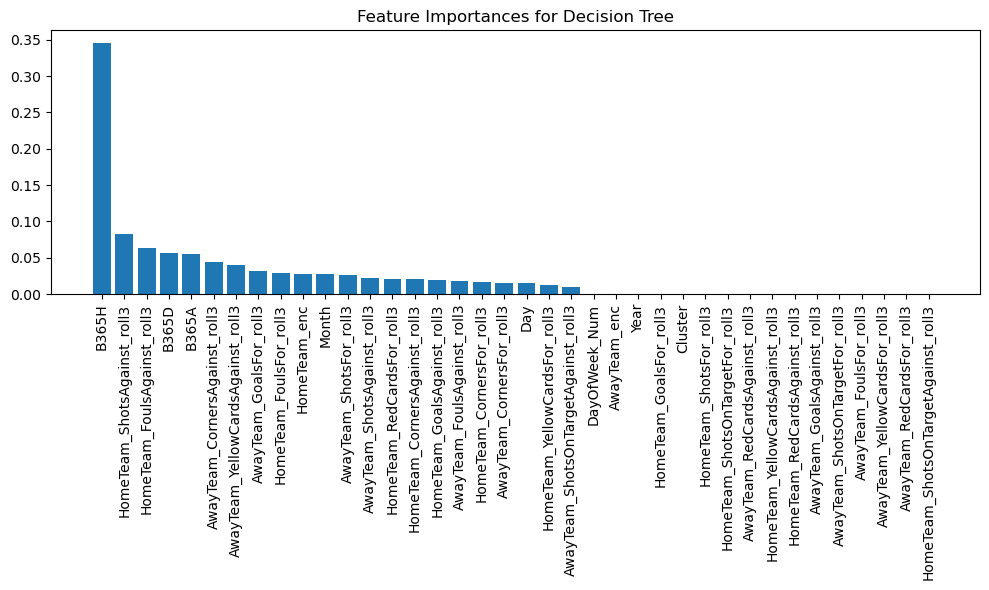


Processing Random Forest...


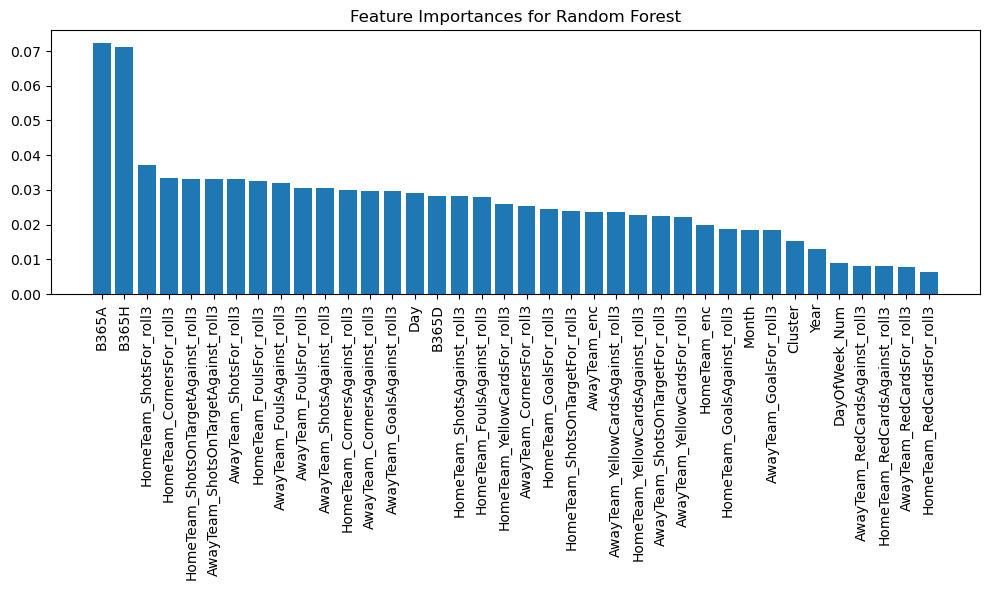


Processing Support Vector Machine...
Model Support Vector Machine does not support feature importances. Skipping.

Processing XGBoost...


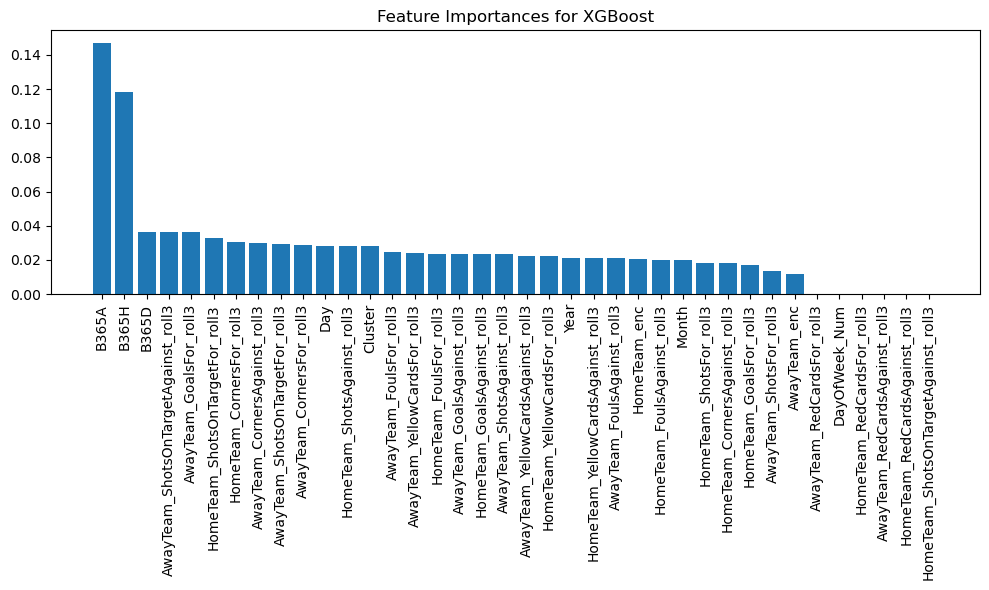


Processing K-Nearest Neighbors...
Model K-Nearest Neighbors does not support feature importances. Skipping.

Processing Naive Bayes...
Model Naive Bayes does not support feature importances. Skipping.

Processing Neural Network...
Model Neural Network does not support feature importances. Skipping.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importances(feature_names, importances, model_name):
    # Sort features by importance
    indices = np.argsort(np.abs(importances))[::-1]
    sorted_features = [feature_names[i] for i in indices]
    sorted_importances = importances[indices]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.title(f'Feature Importances for {model_name}')
    plt.bar(range(len(importances)), sorted_importances, align='center')
    plt.xticks(range(len(importances)), sorted_features, rotation=90)
    plt.tight_layout()
    plt.show()
    
for result in results:
    model_name = result['Model']
    best_estimator = result.get('Best Estimator', None)
    print(f"\nProcessing {model_name}...")
    
    # Skip models without best estimator
    if not best_estimator:
        print(f"No best estimator found for {model_name}. Skipping.")
        continue
    
    # Get the trained model from the pipeline
    model = best_estimator.named_steps['model']
    
    # Get feature names
    feature_names = get_feature_names(best_estimator.named_steps['preprocessor'])
    
    # Check if the model has feature importances
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        plot_feature_importances(feature_names, importances, model_name)
        
    elif hasattr(model, 'coef_'):
        # For models like Logistic Regression
        importances = model.coef_[0]
        plot_feature_importances(feature_names, importances, model_name)
        
    else:
        print(f"Model {model_name} does not support feature importances. Skipping.")



Processing Logistic Regression...


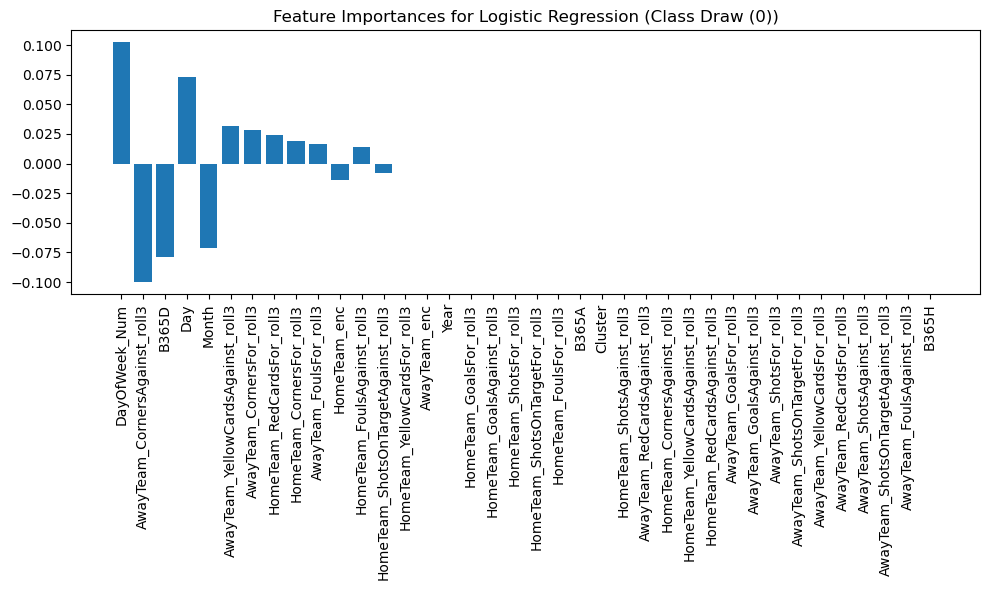

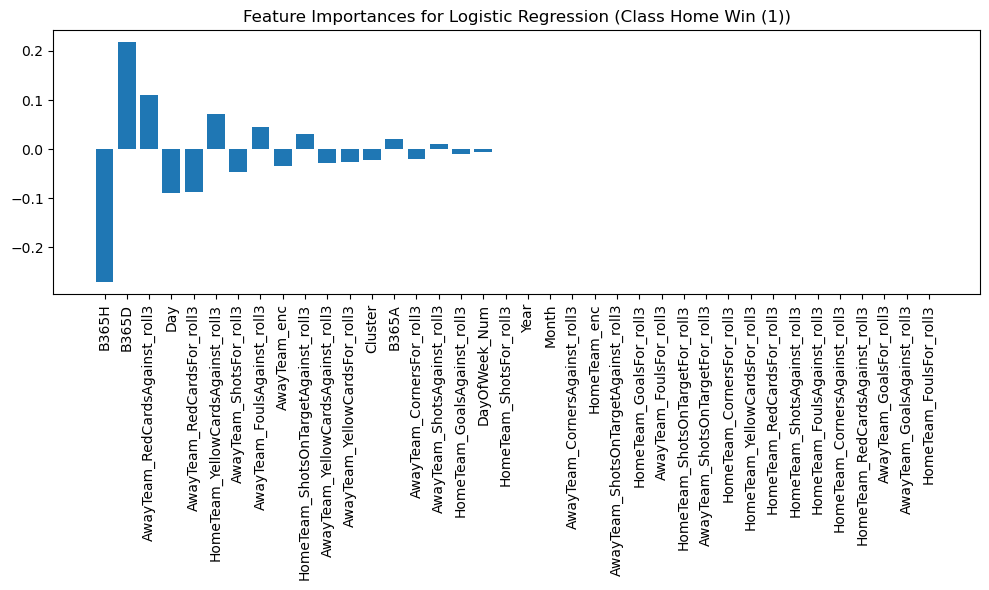

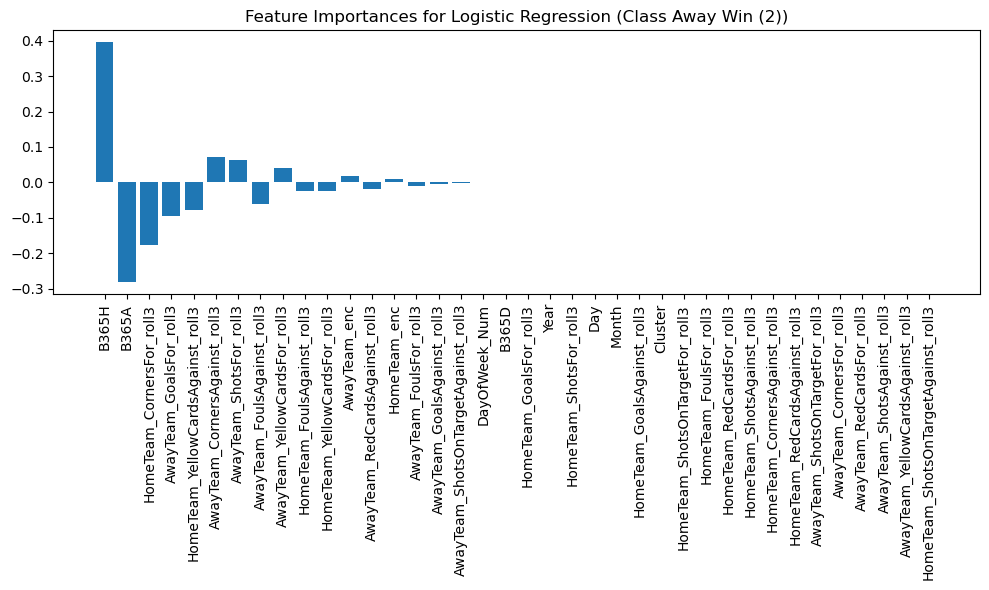


Processing Decision Tree...


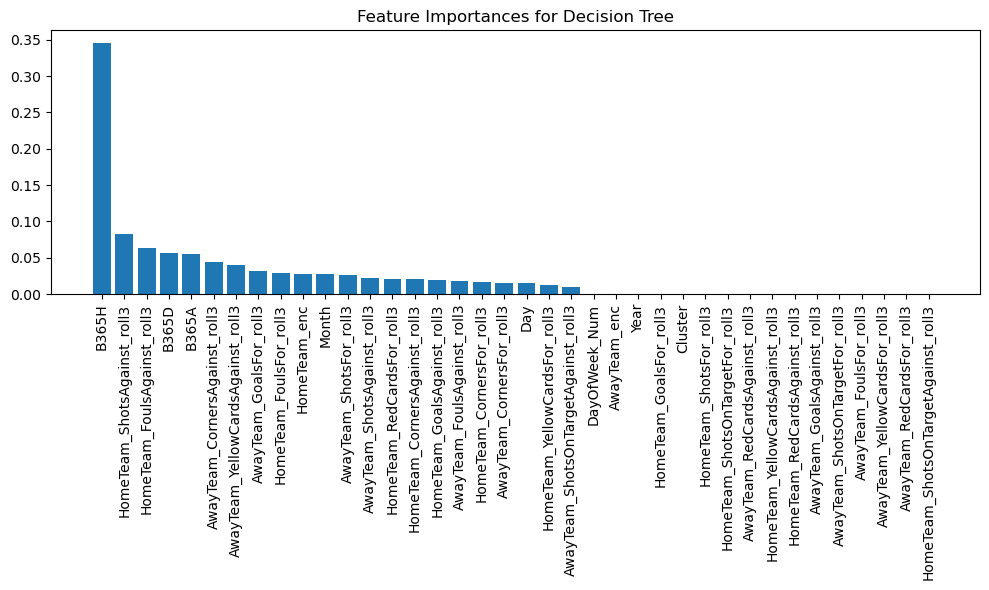


Processing Random Forest...


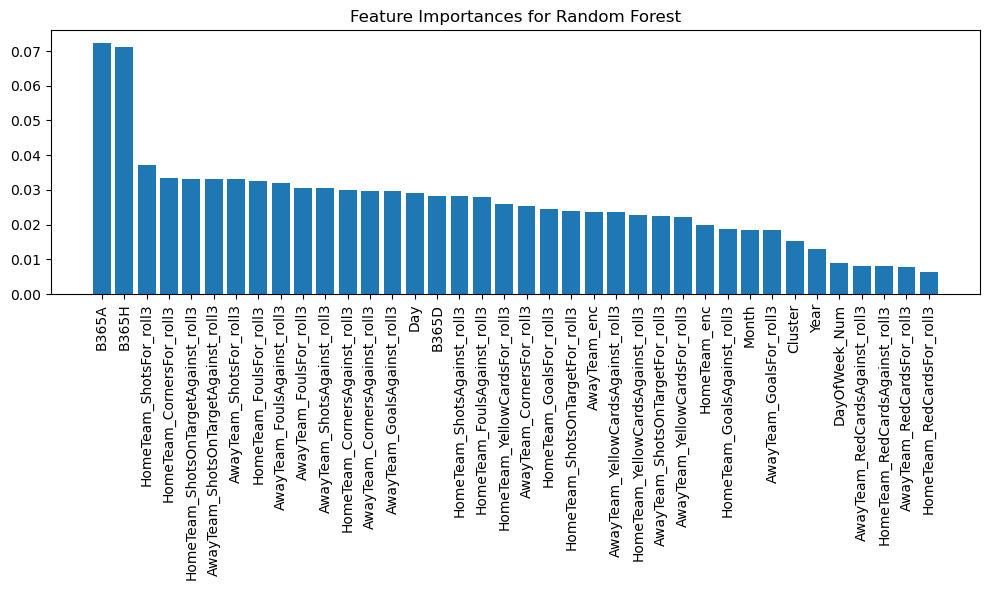


Processing Support Vector Machine...
Model Support Vector Machine does not support feature importances. Skipping.

Processing XGBoost...


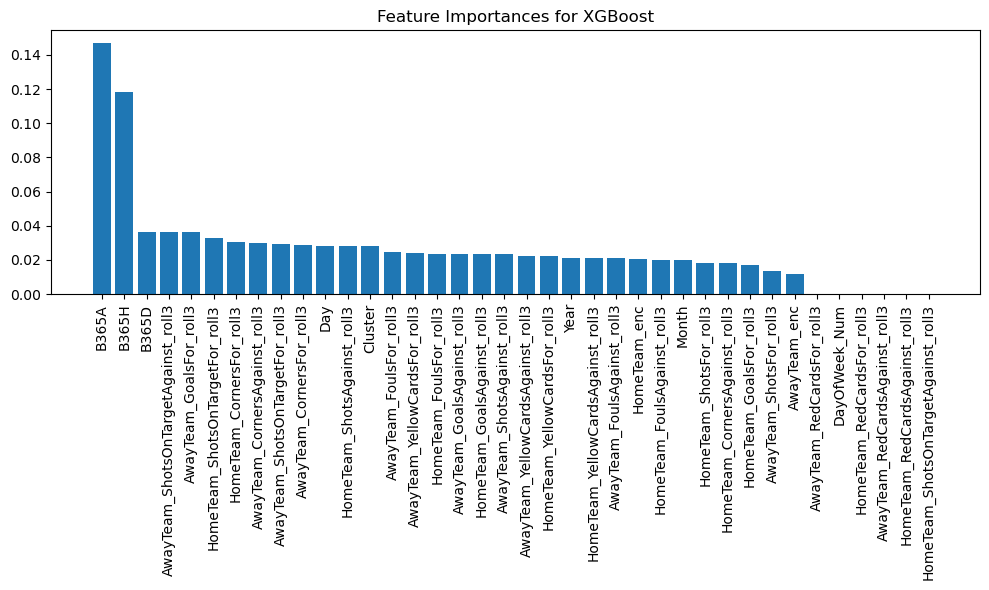


Processing K-Nearest Neighbors...
Model K-Nearest Neighbors does not support feature importances. Skipping.

Processing Naive Bayes...


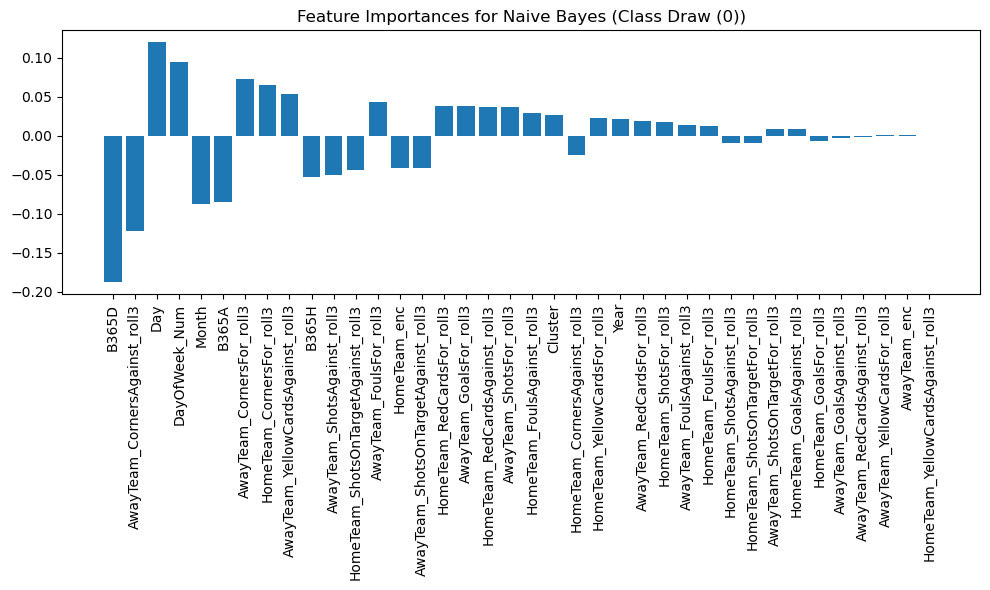

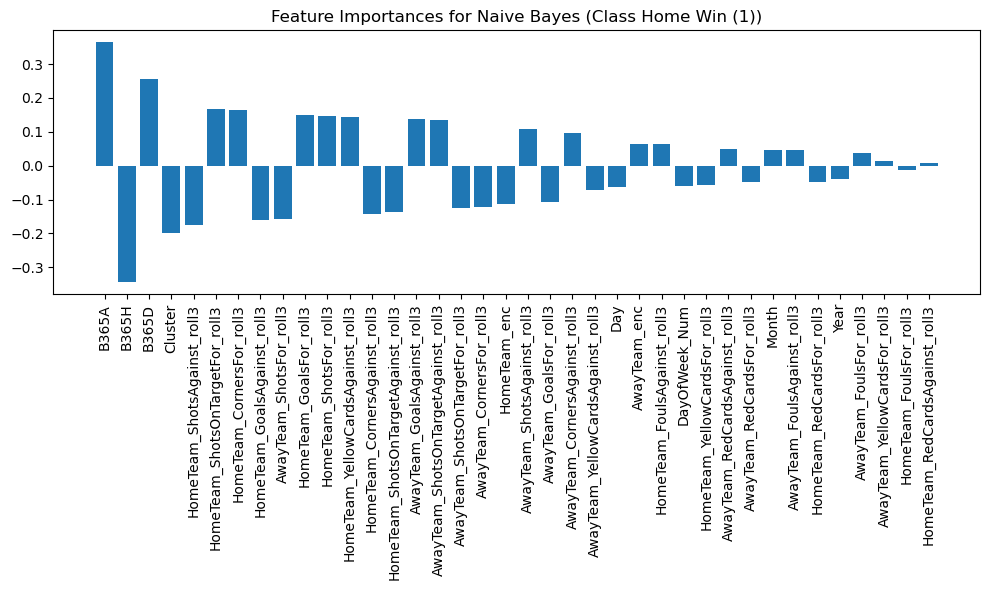

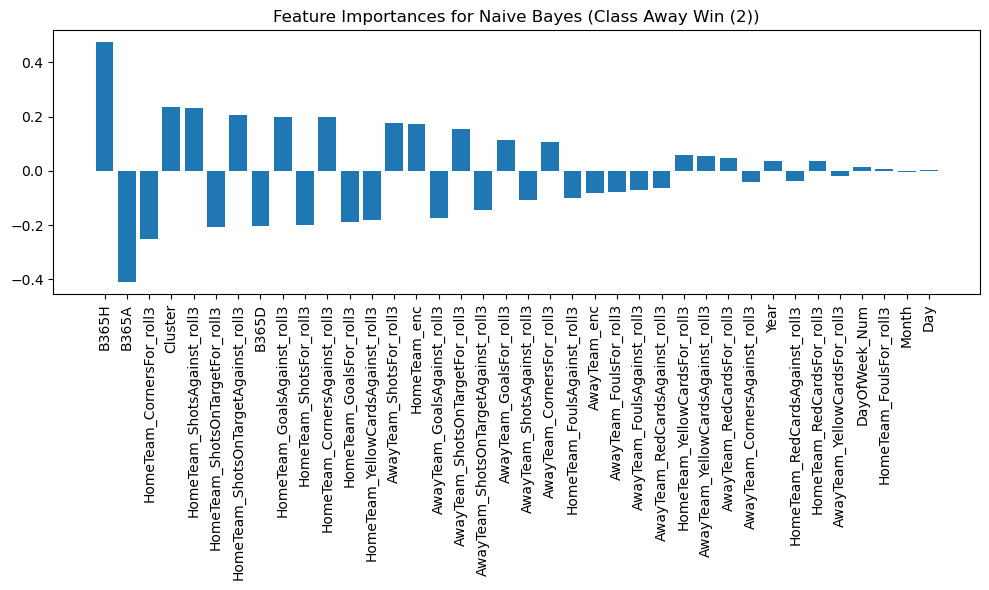


Processing Neural Network...
Model Neural Network does not support feature importances. Skipping.


In [ ]:
for result in results:
    model_name = result['Model']
    best_estimator = result.get('Best Estimator', None)
    print(f"\nProcessing {model_name}...")
    
    # Skip models without best estimator
    if not best_estimator:
        print(f"No best estimator found for {model_name}. Skipping.")
        continue
    
    # Get the trained model from the pipeline
    model = best_estimator.named_steps['model']
    
    # Get feature names
    feature_names = get_feature_names(best_estimator.named_steps['preprocessor'])
    
    # Check if the model has feature importances
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        plot_feature_importances(feature_names, importances, model_name)
        
    elif model_name == 'Logistic Regression' and hasattr(model, 'coef_'):
        # For multiclass classifiers
        n_classes = model.coef_.shape[0]
        for i in range(n_classes):
            class_coef = model.coef_[i]
            class_name = target_names[i]
            plot_feature_importances(feature_names, class_coef, f"{model_name} (Class {class_name})")
            
    elif model_name == 'Support Vector Machine' and hasattr(model, 'coef_'):
        n_classes = model.coef_.shape[0]
        for i in range(n_classes):
            class_coef = model.coef_[i]
            class_name = target_names[i]
            plot_feature_importances(feature_names, class_coef, f"{model_name} (Class {class_name})")
            
    elif model_name == 'Naive Bayes' and hasattr(model, 'theta_'):
        n_classes = model.theta_.shape[0]
        for i in range(n_classes):
            class_theta = model.theta_[i]
            class_name = target_names[i]
            plot_feature_importances(feature_names, class_theta, f"{model_name} (Class {class_name})")
    else:
        print(f"Model {model_name} does not support feature importances. Skipping.")


# confusion matrix of each model

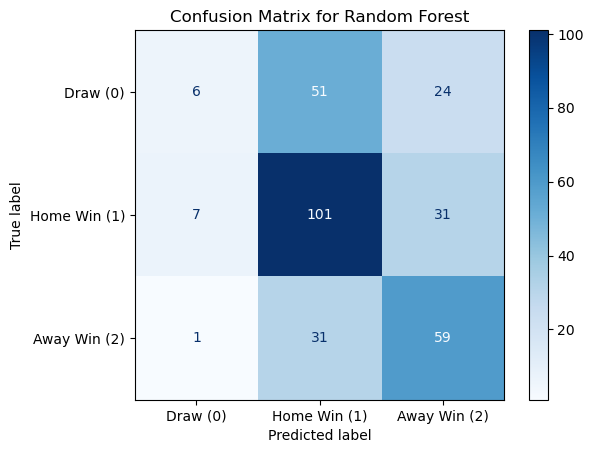

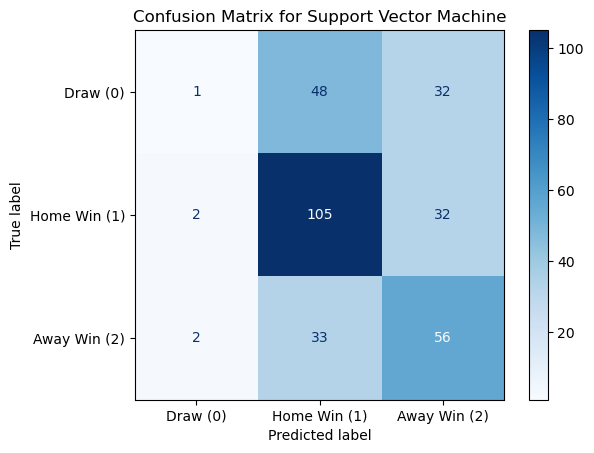

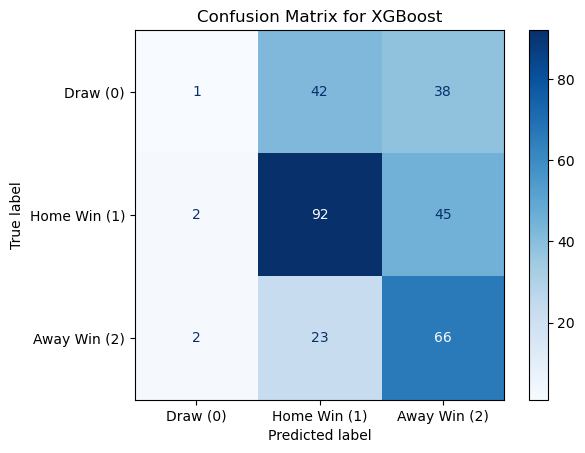

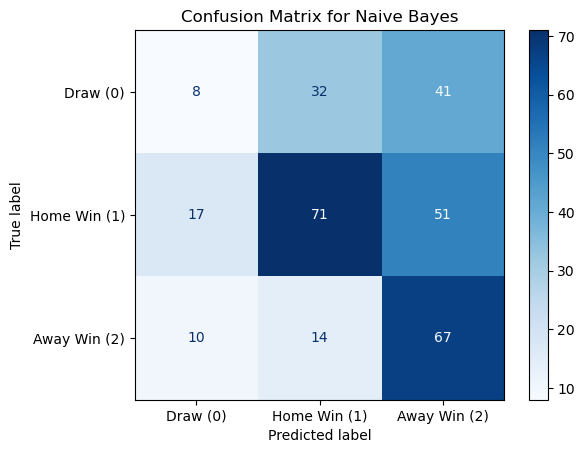

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# List of models for which we want to plot confusion matrices
models_to_plot = ['Naive Bayes', 'Random Forest', 'XGBoost', 'Support Vector Machine']

for result in results:
    model_name = result['Model']
    if model_name in models_to_plot:
        best_estimator = result.get('Best Estimator', None)
        if best_estimator is None:
            print(f"No best estimator found for {model_name}. Skipping.")
            continue

        # Get the trained model from the pipeline
        model = best_estimator.named_steps['model']

        # Make predictions on the test set
        y_pred = best_estimator.predict(X_test)

        # Compute confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

        # Define class names
        class_names = ['Draw (0)', 'Home Win (1)', 'Away Win (2)']

        # Plot confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix for {model_name}')
        plt.show()


Interpreting the Confusion Matrices
The confusion matrix provides a summary of prediction results on the test dataset. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

Diagonal Elements: Correct predictions.
Off-Diagonal Elements: Incorrect predictions.
Example Interpretation
Assuming you have plotted the confusion matrix for Naive Bayes:

True Positive (TP): Number of correct predictions for each class.
False Positive (FP): Number of instances incorrectly predicted as a class.
False Negative (FN): Number of instances of a class incorrectly predicted as another class.
By analyzing the confusion matrices, you can identify which classes are being predicted well and which are causing confusion for the model.



# model ensembling to improve prediction

Ensemble Methods: Techniques that combine multiple machine learning models to improve predictive performance.

Types of Ensembles:

Voting Classifier: Combines the predictions of multiple models using a majority vote or weighted vote (hard voting) or averaging 

probabilities (soft voting).

Stacking Classifier: Trains a meta-model using the outputs of base models as inputs.

For this task, we'll implement both the Voting Classifier and the Stacking Classifier to see which ensemble method performs better.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier

Building the Ensemble Models

2.1. Define Base Models

We need to define the base models with their best parameters (if available). If you have best parameters from previous grid searches, you

 can use them here.

In [ ]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

model_svc = SVC(
    C=0.1,
    kernel='linear',
    probability=True,
    random_state=42
)

model_nb = GaussianNB()


pipeline for each model

In [ ]:
# Pipelines for each model
pipeline_nb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_nb)
])

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_rf)
])

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_xgb)
])

pipeline_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_svc)
])


Define the Voting Classifier

We'll use soft voting to average the predicted probabilities

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_classifier = VotingClassifier(
    estimators=[
        ('nb', pipeline_nb),
        ('rf', pipeline_rf),
        ('xgb', pipeline_xgb),
        ('svc', pipeline_svc)
    ],
    voting='soft',  # Use soft voting
    n_jobs=-1
)


Trainning the voting classifier

In [ ]:
# Fit the ensemble model
voting_classifier.fit(X_train, y_train)


VotingClassifier(estimators=[('nb',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                Pipeline(steps=[('imputer',
                                                                                                 SimpleImputer()),
                                                                                                ('scaler',
                                                                                                 StandardScaler())]),
                                                                                ['B365H',
                                                                                 'B365D',
                                                                                 'B365A',
                                                                                 'Year',
                                                                                 'Month',
                                                                                 'Day',
                                                                                 'HomeTeam_enc',
                                                                                 'AwayTeam_enc',
                                                                                 'DayOfWeek_Num',
                                                                                 'HomeTeam_GoalsFor_roll3',
                                                                                 'HomeTeam_GoalsAgainst_roll3',
                                                                                 'HomeTeam_ShotsFor_rol...
                                                                                 'HomeTeam_YellowCardsAgainst_roll3',
                                                                                 'HomeTeam_RedCardsAgainst_roll3',
                                                                                 'AwayTeam_GoalsFor_roll3',
                                                                                 'AwayTeam_GoalsAgainst_roll3',
                                                                                 'AwayTeam_ShotsFor_roll3',
                                                                                 'AwayTeam_ShotsOnTargetFor_roll3',
                                                                                 'AwayTeam_FoulsFor_roll3',
                                                                                 'AwayTeam_CornersFor_roll3',
                                                                                 'AwayTeam_YellowCardsFor_roll3', ...])])),
                                              ('model',
                                               SVC(C=0.1, kernel='linear',
                                                   probability=True,
                                                   random_state=42))]))],
                 n_jobs=-1, voting='soft')

Evaluating voting classifier

In [ ]:
# Predict on test data
y_pred = voting_classifier.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted'
)

# Print results
print("Voting Classifier Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

# Classification report
target_names = ['Draw (0)', 'Home Win (1)', 'Away Win (2)']
print(classification_report(y_test, y_pred, target_names=target_names))


Voting Classifier Performance:
Accuracy: 0.5145
Precision: 0.4771, Recall: 0.5145, F1 Score: 0.4579
              precision    recall  f1-score   support

    Draw (0)       0.30      0.04      0.07        81
Home Win (1)       0.60      0.65      0.62       139
Away Win (2)       0.44      0.74      0.55        91

    accuracy                           0.51       311
   macro avg       0.45      0.47      0.41       311
weighted avg       0.48      0.51      0.46       311



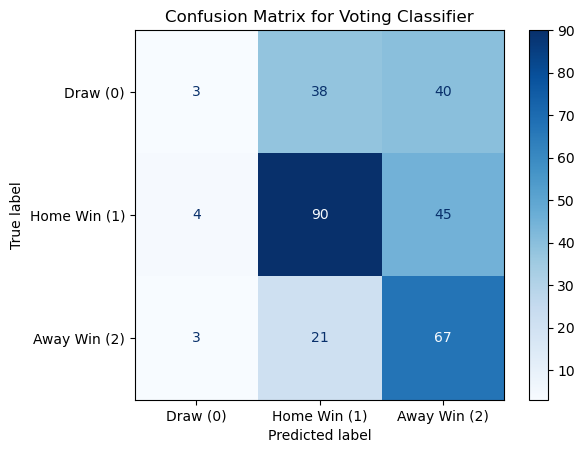

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Voting Classifier')
plt.show()


Implement the Updated Stacking Classifier
4.1. Define the Stacking Classifier
We'll use a Logistic Regression model as the meta-classifier.

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base estimators
estimators = [
    ('nb', pipeline_nb),
    ('rf', pipeline_rf),
    ('xgb', pipeline_xgb),
    ('svc', pipeline_svc)
]

# Define meta-classifier
meta_classifier = LogisticRegression(max_iter=1000, random_state=42)

# Create the stacking classifier
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_classifier,
    cv=5,  # Number of cross-validation folds
    n_jobs=-1,
    passthrough=False  # Do not pass original features to meta-classifier
)


In [ ]:
# Fit the stacking classifier
stacking_classifier.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('nb',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer()),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())]),
                                                                                  ['B365H',
                                                                                   'B365D',
                                                                                   'B365A',
                                                                                   'Year',
                                                                                   'Month',
                                                                                   'Day',
                                                                                   'HomeTeam_enc',
                                                                                   'AwayTeam_enc',
                                                                                   'DayOfWeek_Num',
                                                                                   'HomeTeam_GoalsFor_roll3',
                                                                                   'HomeTeam_GoalsAgainst_roll3',
                                                                                   'HomeTeam_Shots...
                                                                                   'AwayTeam_GoalsFor_roll3',
                                                                                   'AwayTeam_GoalsAgainst_roll3',
                                                                                   'AwayTeam_ShotsFor_roll3',
                                                                                   'AwayTeam_ShotsOnTargetFor_roll3',
                                                                                   'AwayTeam_FoulsFor_roll3',
                                                                                   'AwayTeam_CornersFor_roll3',
                                                                                   'AwayTeam_YellowCardsFor_roll3', ...])])),
                                                ('model',
                                                 SVC(C=0.1, kernel='linear',
                                                     probability=True,
                                                     random_state=42))]))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)

In [ ]:
# Predict on test data
y_pred_stack = stacking_classifier.predict(X_test)

# Calculate metrics
accuracy_stack = accuracy_score(y_test, y_pred_stack)
precision_stack, recall_stack, f1_stack, _ = precision_recall_fscore_support(
    y_test, y_pred_stack, average='weighted'
)

# Print results
print("Stacking Classifier Performance:")
print(f"Accuracy: {accuracy_stack:.4f}")
print(f"Precision: {precision_stack:.4f}, Recall: {recall_stack:.4f}, F1 Score: {f1_stack:.4f}")

# Classification report
print(classification_report(y_test, y_pred_stack, target_names=target_names))


Stacking Classifier Performance:
Accuracy: 0.5402
Precision: 0.4024, Recall: 0.5402, F1 Score: 0.4606
              precision    recall  f1-score   support

    Draw (0)       0.00      0.00      0.00        81
Home Win (1)       0.59      0.74      0.65       139
Away Win (2)       0.48      0.71      0.58        91

    accuracy                           0.54       311
   macro avg       0.36      0.49      0.41       311
weighted avg       0.40      0.54      0.46       311



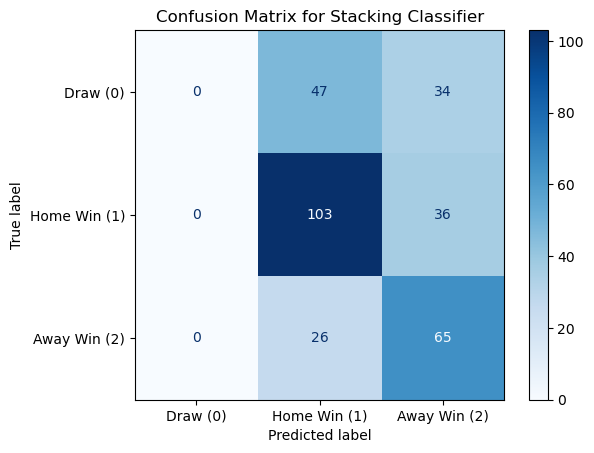

In [ ]:
# Compute confusion matrix
cm_stack = confusion_matrix(y_test, y_pred_stack, labels=[0, 1, 2])

# Plot confusion matrix
disp_stack = ConfusionMatrixDisplay(confusion_matrix=cm_stack, display_labels=target_names)
disp_stack.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Stacking Classifier')
plt.show()


In [ ]:
ensemble_results = [
    {
        'Model': 'Voting Classifier',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    },
    {
        'Model': 'Stacking Classifier',
        'Accuracy': accuracy_stack,
        'Precision': precision_stack,
        'Recall': recall_stack,
        'F1 Score': f1_stack
    }
]

# Convert to DataFrame
ensemble_results_df = pd.DataFrame(ensemble_results)


In [ ]:
print("\nEnsemble Model Comparison:")
print(ensemble_results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']])



Ensemble Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0    Voting Classifier  0.514469   0.477079  0.514469  0.457867
1  Stacking Classifier  0.540193   0.402448  0.540193  0.460600


Compare Ensemble Model Performances

5.1. Collect Results

#  USING BORUTA FEATURE SELECTION METHOD TO RE RUN THE MODELS

Steps

Install Boruta Package (if not installed).

Run Boruta for Feature Selection on the training dataset.

Filter the Selected Features based on Boruta’s output.

Train and Test Model Using Selected Features.

In [ ]:
#!pip install boruta


In [ ]:
print(X_train.isnull().sum())


B365H                                  1
B365D                                  1
B365A                                  1
Year                                   0
Month                                  0
Day                                    0
HomeTeam_enc                           0
AwayTeam_enc                           0
DayOfWeek_Num                          0
HomeTeam_GoalsFor_roll3                0
HomeTeam_GoalsAgainst_roll3            0
HomeTeam_ShotsFor_roll3                0
HomeTeam_ShotsOnTargetFor_roll3        0
HomeTeam_FoulsFor_roll3                0
HomeTeam_CornersFor_roll3              0
HomeTeam_YellowCardsFor_roll3          0
HomeTeam_RedCardsFor_roll3             0
HomeTeam_ShotsAgainst_roll3            0
HomeTeam_ShotsOnTargetAgainst_roll3    0
HomeTeam_FoulsAgainst_roll3            0
HomeTeam_CornersAgainst_roll3          0
HomeTeam_YellowCardsAgainst_roll3      0
HomeTeam_RedCardsAgainst_roll3         0
AwayTeam_GoalsFor_roll3                0
AwayTeam_GoalsAg

In [ ]:
# Drop rows with missing values
X_train.dropna(inplace=True)


In [ ]:
# Drop rows with missing values in X_train
X_train = X_train.dropna()

# Align y_train with the updated X_train
y_train = y_train.loc[X_train.index]


In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


X_train shape: (1136, 38)
y_train shape: (1136,)


In [ ]:
import pandas as pd
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Check for categorical columns and encode if needed
categorical_cols = X_train.select_dtypes(include=['category', 'object']).columns

if len(categorical_cols) > 0:
    X_train = pd.get_dummies(X_train, columns=categorical_cols)

# Initialize the random forest model and Boruta feature selector
rf = RandomForestClassifier(n_jobs=-1, max_depth=5, random_state=42)
boruta_selector = BorutaPy(rf, n_estimators='auto', random_state=42)

# Fit Boruta on the training data
boruta_selector.fit(X_train.to_numpy(), y_train.to_numpy())

# Get the selected features
selected_features = X_train.columns[boruta_selector.support_].tolist()
print("Selected features by Boruta:", selected_features)


Selected features by Boruta: ['B365H', 'B365D', 'B365A', 'HomeTeam_ShotsOnTargetFor_roll3', 'HomeTeam_CornersFor_roll3', 'HomeTeam_ShotsAgainst_roll3', 'HomeTeam_ShotsOnTargetAgainst_roll3', 'HomeTeam_YellowCardsAgainst_roll3', 'AwayTeam_GoalsAgainst_roll3', 'AwayTeam_ShotsFor_roll3', 'AwayTeam_ShotsOnTargetAgainst_roll3', 'Cluster']


In [ ]:
# Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, selected_features)
])

# Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2']
}

# Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'model__max_depth': [None, 5, 10,15,20,25],
    'model__min_samples_split': [2, 5,10]
}

# Random Forest
model_rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'model__n_estimators': [50,100,150, 200,250,300],
    'model__max_depth': [None, 5, 10,20],
    'model__min_samples_split': [2, 5,10]
}

# Support Vector Machine
model_svc = SVC(random_state=42, probability=True)
param_grid_svc = {
    'model__C': [0.1, 1, 10,100],
    'model__kernel': ['linear', 'rbf']
}

# XGBoost
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
param_grid_xgb = {
    'model__n_estimators': [50,100,150, 200,250,300],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5]
}

# K-Nearest Neighbors
model_knn = KNeighborsClassifier()
param_grid_knn = {
    'model__n_neighbors': [5, 10,15,20],
    'model__weights': ['uniform', 'distance']
}

# Naive Bayes
model_nb = GaussianNB()
param_grid_nb = {}  # No hyperparameters to tune

# List of models
models = [
    ('Logistic Regression', model_lr, param_grid_lr),
    ('Decision Tree', model_dt, param_grid_dt),
    ('Random Forest', model_rf, param_grid_rf),
    ('Support Vector Machine', model_svc, param_grid_svc),
    ('XGBoost', model_xgb, param_grid_xgb),
    ('K-Nearest Neighbors', model_knn, param_grid_knn),
    ('Naive Bayes', model_nb, param_grid_nb)
]

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

results = []

for name, model, param_grid in models:
    print(f"\nTraining {name}...")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Use 'f1_weighted' as scoring metric
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_estimator = grid_search.best_estimator_
        best_params = grid_search.best_params_
    else:
        best_estimator = pipeline.fit(X_train, y_train)
        best_params = {}
    
    y_pred = best_estimator.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Best Parameters': best_params,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
    
    # Define target names
    target_names = ['Draw (0)', 'Home Win (1)', 'Away Win (2)']
    
    print(f"Best Parameters for {name}: {best_params}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))



Training Logistic Regression...
Best Parameters for Logistic Regression: {'model__C': 0.01, 'model__penalty': 'l2'}
Accuracy: 0.5241
Precision: 0.3920, Recall: 0.5241, F1 Score: 0.4473
              precision    recall  f1-score   support

    Draw (0)       0.00      0.00      0.00        81
Home Win (1)       0.57      0.71      0.63       139
Away Win (2)       0.46      0.71      0.56        91

    accuracy                           0.52       311
   macro avg       0.35      0.47      0.40       311
weighted avg       0.39      0.52      0.45       311


Training Decision Tree...
Best Parameters for Decision Tree: {'model__max_depth': 5, 'model__min_samples_split': 2}
Accuracy: 0.4373
Precision: 0.4185, Recall: 0.4373, F1 Score: 0.4011
              precision    recall  f1-score   support

    Draw (0)       0.25      0.05      0.08        81
Home Win (1)       0.57      0.57      0.57       139
Away Win (2)       0.34      0.58      0.43        91

    accuracy                 

In [ ]:
# Training and evaluating models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

results = []

for name, model, param_grid in models:
    print(f"\nTraining {name}...")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Use 'f1_weighted' as scoring metric
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_estimator = grid_search.best_estimator_
        best_params = grid_search.best_params_
    else:
        best_estimator = pipeline.fit(X_train, y_train)
        best_params = {}
    
    y_pred = best_estimator.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Best Parameters': best_params,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Best Estimator': best_estimator  # Store the best estimator
    })
    
    # Convert class labels to strings for classification report
    target_names = ['Draw (0)', 'Home Win (1)', 'Away Win (2)']
    
    print(f"Best Parameters for {name}: {best_params}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))



Training Logistic Regression...
Best Parameters for Logistic Regression: {'model__C': 0.01, 'model__penalty': 'l2'}
Accuracy: 0.5241
Precision: 0.3920, Recall: 0.5241, F1 Score: 0.4473
              precision    recall  f1-score   support

    Draw (0)       0.00      0.00      0.00        81
Home Win (1)       0.57      0.71      0.63       139
Away Win (2)       0.46      0.71      0.56        91

    accuracy                           0.52       311
   macro avg       0.35      0.47      0.40       311
weighted avg       0.39      0.52      0.45       311


Training Decision Tree...
Best Parameters for Decision Tree: {'model__max_depth': 5, 'model__min_samples_split': 2}
Accuracy: 0.4373
Precision: 0.4185, Recall: 0.4373, F1 Score: 0.4011
              precision    recall  f1-score   support

    Draw (0)       0.25      0.05      0.08        81
Home Win (1)       0.57      0.57      0.57       139
Away Win (2)       0.34      0.58      0.43        91

    accuracy                 

In [ ]:
# Create a DataFrame from results
results_df = pd.DataFrame(results)

# Sort the results by F1 Score
results_df.sort_values(by='F1 Score', ascending=False, inplace=True)

# Display the results
print("\nModel Comparison:")
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Best Parameters']].head(8))



Model Comparison:
                    Model  Accuracy  Precision    Recall  F1 Score  \
2           Random Forest  0.527331   0.528779  0.527331  0.497988   
5     K-Nearest Neighbors  0.479100   0.448046  0.479100  0.458230   
4                 XGBoost  0.482315   0.454159  0.482315  0.451562   
0     Logistic Regression  0.524116   0.391996  0.524116  0.447254   
6             Naive Bayes  0.472669   0.495954  0.472669  0.436430   
3  Support Vector Machine  0.440514   0.421940  0.440514  0.422043   
1           Decision Tree  0.437299   0.418542  0.437299  0.401071   

                                     Best Parameters  
2  {'model__max_depth': None, 'model__min_samples...  
5  {'model__n_neighbors': 15, 'model__weights': '...  
4  {'model__learning_rate': 0.01, 'model__max_dep...  
0         {'model__C': 0.01, 'model__penalty': 'l2'}  
6                                                 {}  
3           {'model__C': 10, 'model__kernel': 'rbf'}  
1  {'model__max_depth': 5, 'model__


Processing Logistic Regression...


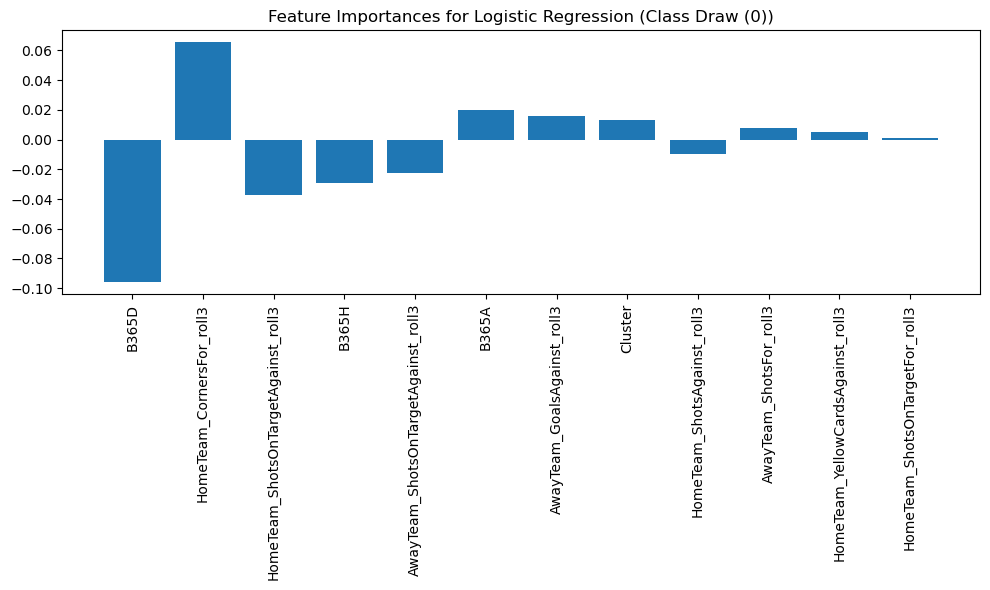

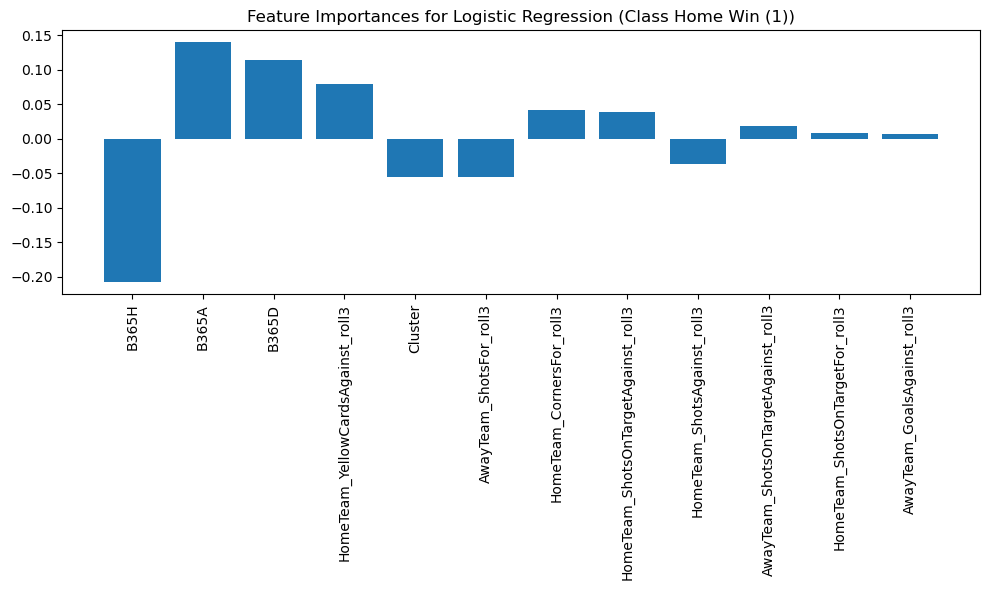

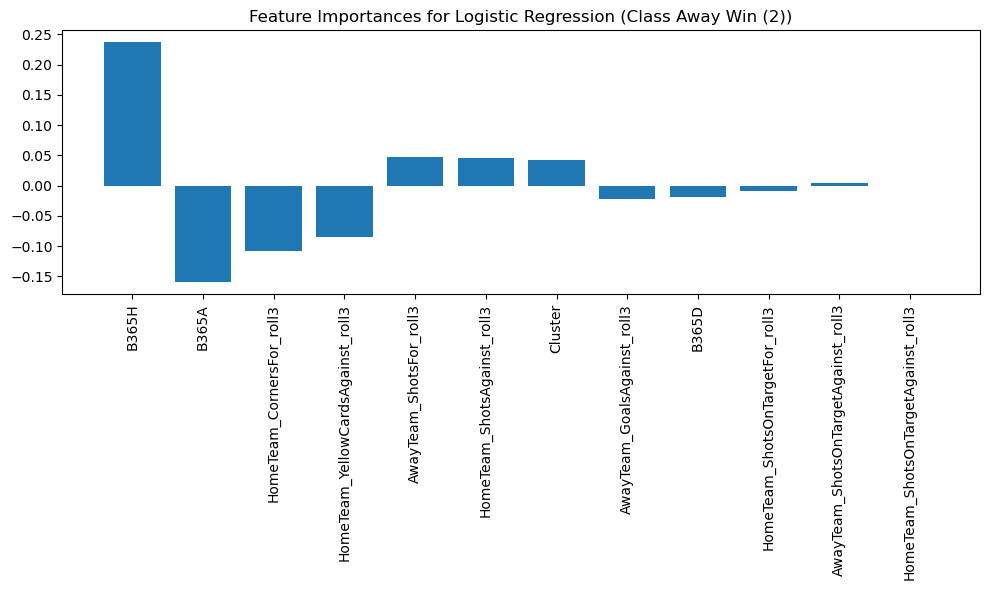


Processing Decision Tree...


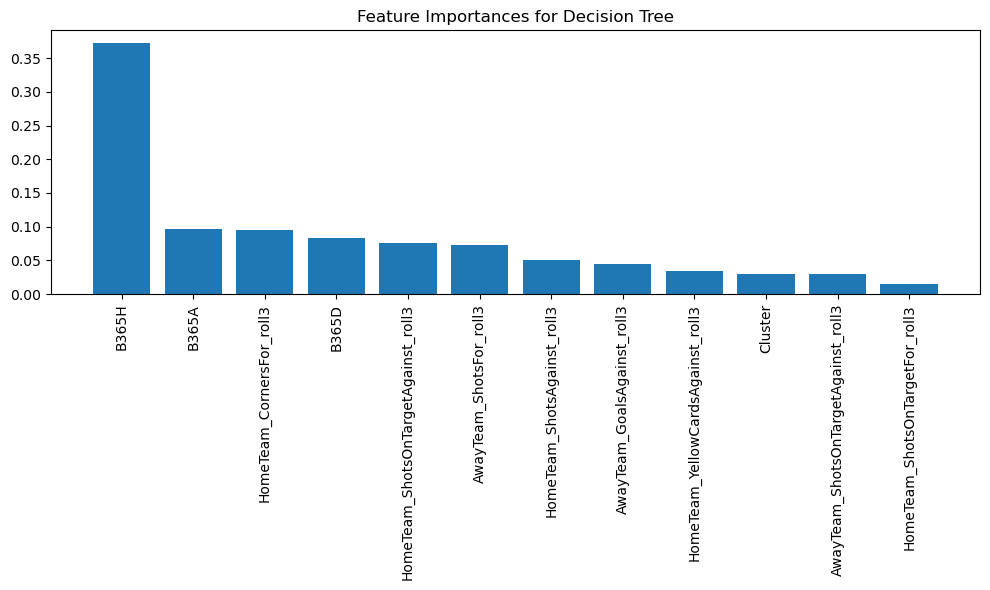


Processing Random Forest...


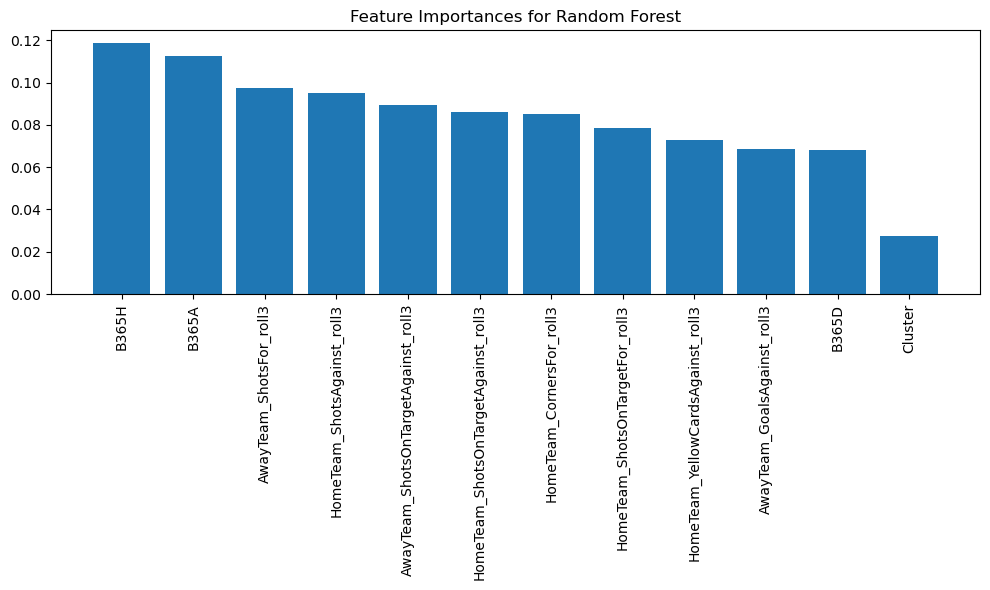


Processing Support Vector Machine...
Model Support Vector Machine does not support feature importances. Skipping.

Processing XGBoost...


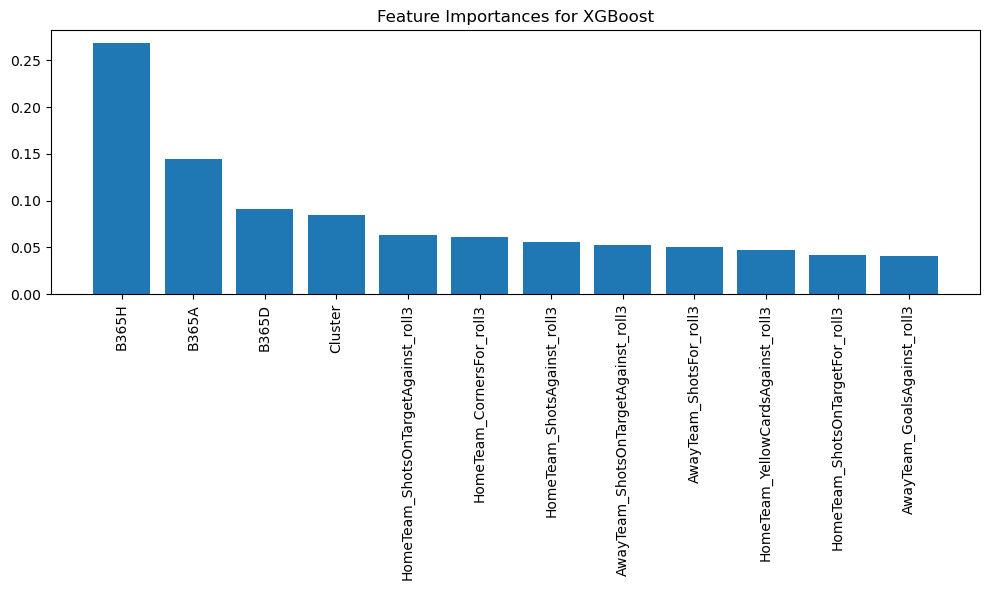


Processing K-Nearest Neighbors...
Model K-Nearest Neighbors does not support feature importances. Skipping.

Processing Naive Bayes...


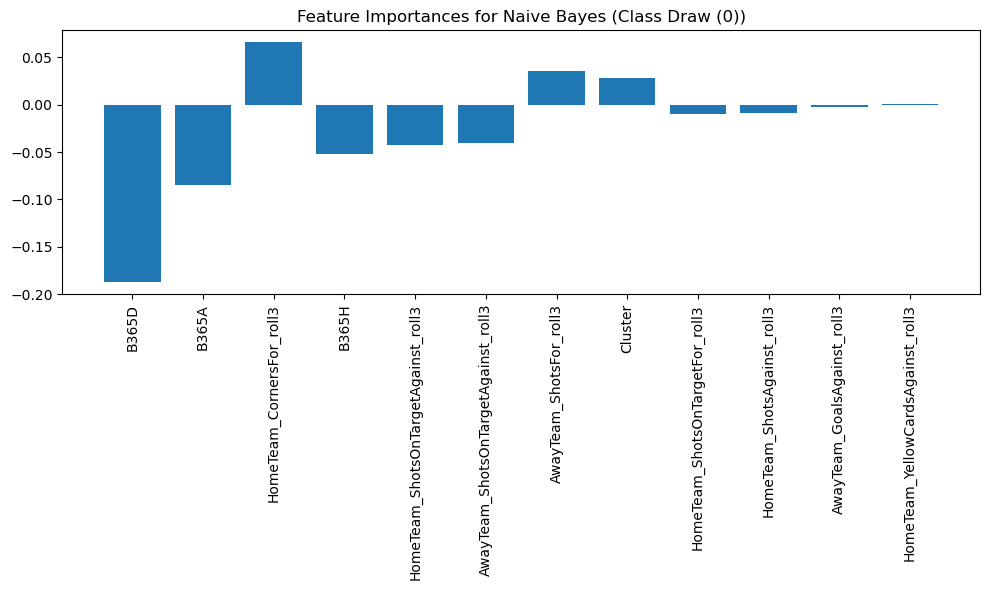

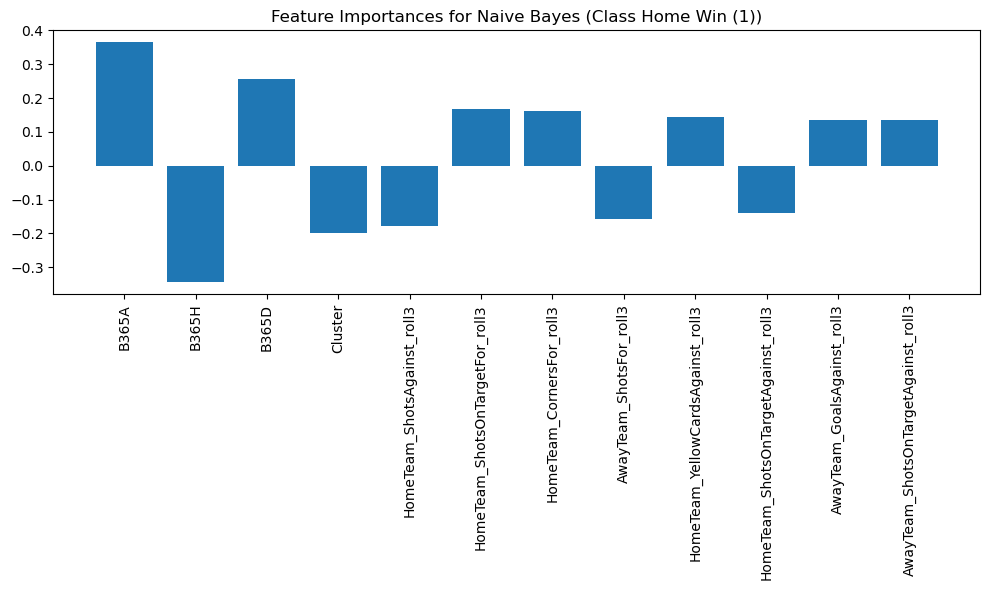

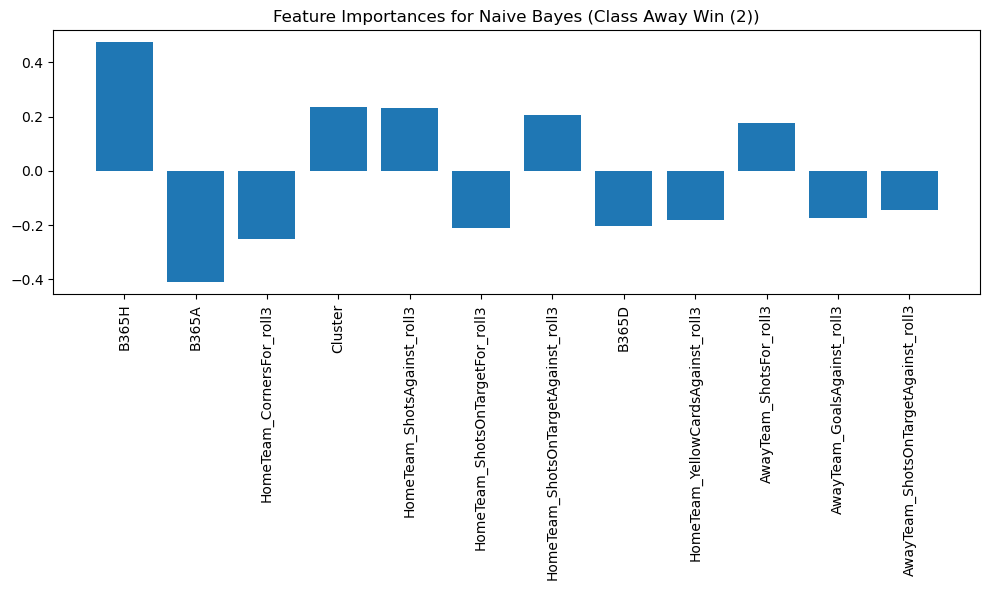

In [ ]:
for result in results:
    model_name = result['Model']
    best_estimator = result.get('Best Estimator', None)
    print(f"\nProcessing {model_name}...")
    
    # Skip models without best estimator
    if not best_estimator:
        print(f"No best estimator found for {model_name}. Skipping.")
        continue
    
    # Get the trained model from the pipeline
    model = best_estimator.named_steps['model']
    
    # Get feature names
    feature_names = get_feature_names(best_estimator.named_steps['preprocessor'])
    
    # Check if the model has feature importances
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        plot_feature_importances(feature_names, importances, model_name)
        
    elif model_name == 'Logistic Regression' and hasattr(model, 'coef_'):
        # For multiclass classifiers
        n_classes = model.coef_.shape[0]
        for i in range(n_classes):
            class_coef = model.coef_[i]
            class_name = target_names[i]
            plot_feature_importances(feature_names, class_coef, f"{model_name} (Class {class_name})")
            
    elif model_name == 'Support Vector Machine' and hasattr(model, 'coef_'):
        n_classes = model.coef_.shape[0]
        for i in range(n_classes):
            class_coef = model.coef_[i]
            class_name = target_names[i]
            plot_feature_importances(feature_names, class_coef, f"{model_name} (Class {class_name})")
            
    elif model_name == 'Naive Bayes' and hasattr(model, 'theta_'):
        n_classes = model.theta_.shape[0]
        for i in range(n_classes):
            class_theta = model.theta_[i]
            class_name = target_names[i]
            plot_feature_importances(feature_names, class_theta, f"{model_name} (Class {class_name})")
    else:
        print(f"Model {model_name} does not support feature importances. Skipping.")


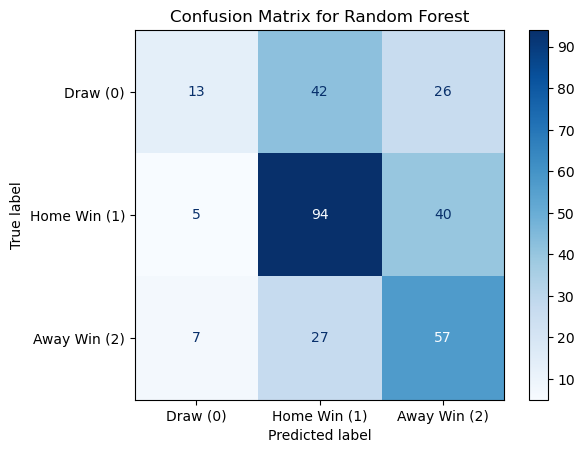

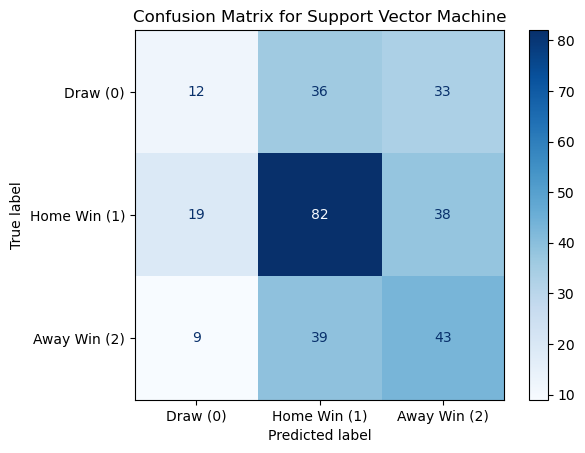

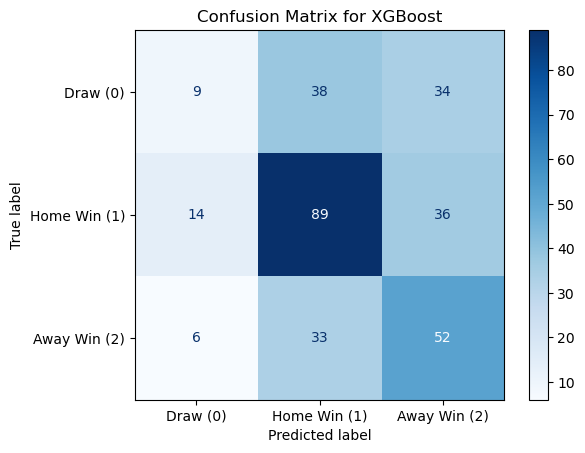

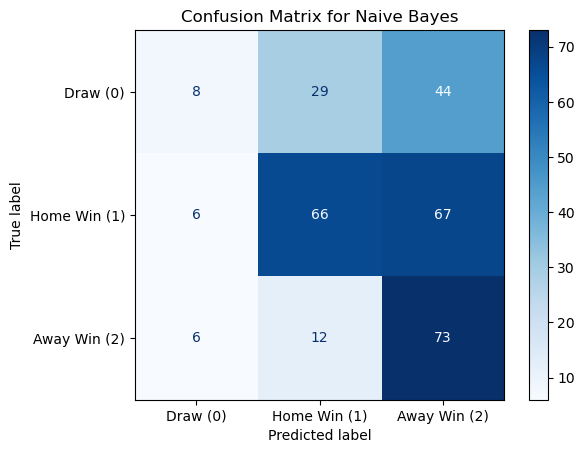

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# List of models for which we want to plot confusion matrices
models_to_plot = ['Naive Bayes', 'Random Forest', 'XGBoost', 'Support Vector Machine']

for result in results:
    model_name = result['Model']
    if model_name in models_to_plot:
        best_estimator = result.get('Best Estimator', None)
        if best_estimator is None:
            print(f"No best estimator found for {model_name}. Skipping.")
            continue

        # Get the trained model from the pipeline
        model = best_estimator.named_steps['model']

        # Make predictions on the test set
        y_pred = best_estimator.predict(X_test)

        # Compute confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

        # Define class names
        class_names = ['Draw (0)', 'Home Win (1)', 'Away Win (2)']

        # Plot confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix for {model_name}')
        plt.show()


In [ ]:
X_train.columns

Index(['B365H', 'B365D', 'B365A', 'Year', 'Month', 'Day', 'HomeTeam_enc',
       'AwayTeam_enc', 'DayOfWeek_Num', 'HomeTeam_GoalsFor_roll3',
       'HomeTeam_GoalsAgainst_roll3', 'HomeTeam_ShotsFor_roll3',
       'HomeTeam_ShotsOnTargetFor_roll3', 'HomeTeam_FoulsFor_roll3',
       'HomeTeam_CornersFor_roll3', 'HomeTeam_YellowCardsFor_roll3',
       'HomeTeam_RedCardsFor_roll3', 'HomeTeam_ShotsAgainst_roll3',
       'HomeTeam_ShotsOnTargetAgainst_roll3', 'HomeTeam_FoulsAgainst_roll3',
       'HomeTeam_CornersAgainst_roll3', 'HomeTeam_YellowCardsAgainst_roll3',
       'HomeTeam_RedCardsAgainst_roll3', 'AwayTeam_GoalsFor_roll3',
       'AwayTeam_GoalsAgainst_roll3', 'AwayTeam_ShotsFor_roll3',
       'AwayTeam_ShotsOnTargetFor_roll3', 'AwayTeam_FoulsFor_roll3',
       'AwayTeam_CornersFor_roll3', 'AwayTeam_YellowCardsFor_roll3',
       'AwayTeam_RedCardsFor_roll3', 'AwayTeam_ShotsAgainst_roll3',
       'AwayTeam_ShotsOnTargetAgainst_roll3', 'AwayTeam_FoulsAgainst_roll3',
       'AwayTeam_C

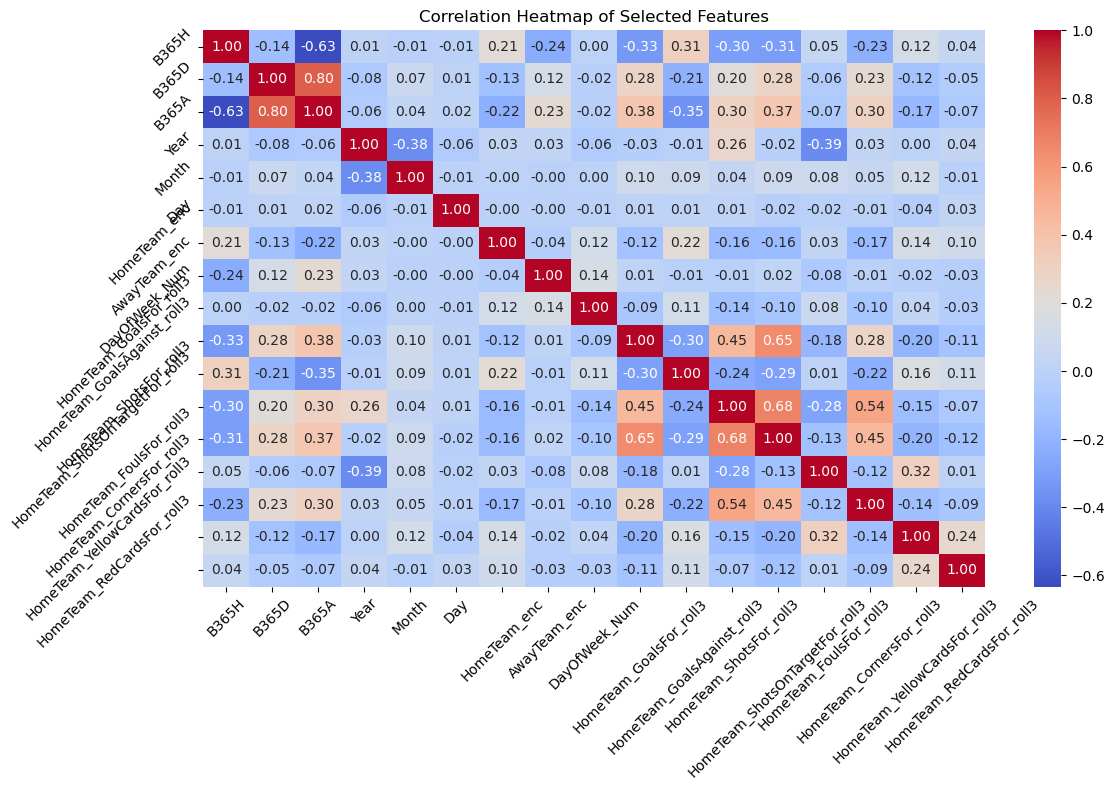

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine the required features into a single DataFrame
correlation_features = data[
    [col for col in data.columns if 'rolling' in col] +  # Rolling features
    ['B365H', 'B365D', 'B365A', 'Year', 'Month', 'Day', 'HomeTeam_enc',
       'AwayTeam_enc', 'DayOfWeek_Num', 'HomeTeam_GoalsFor_roll3',
       'HomeTeam_GoalsAgainst_roll3', 'HomeTeam_ShotsFor_roll3',
       'HomeTeam_ShotsOnTargetFor_roll3', 'HomeTeam_FoulsFor_roll3',
       'HomeTeam_CornersFor_roll3', 'HomeTeam_YellowCardsFor_roll3',
       'HomeTeam_RedCardsFor_roll3']  # Additional features
]

# Calculate the correlation matrix
correlation_matrix = correlation_features.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of Selected Features")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


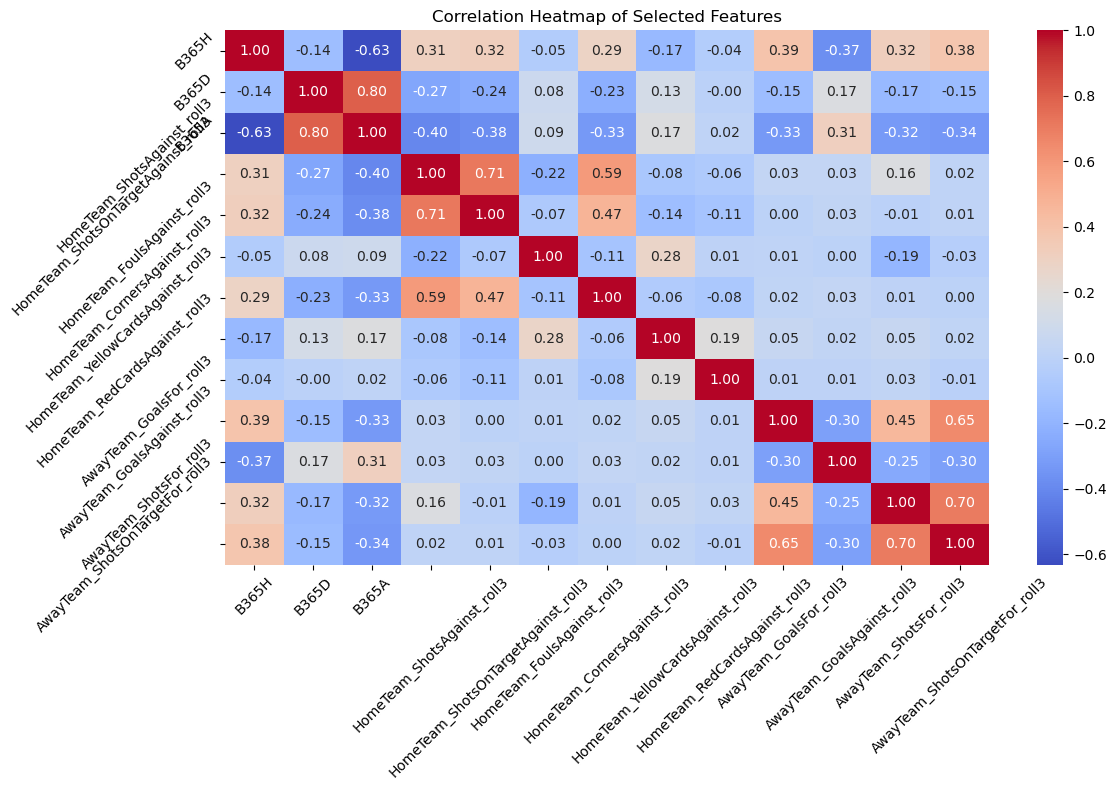

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'correlation_features' and 'correlation_matrix' are already created

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)

# Set title
plt.title("Correlation Heatmap of Selected Features")

# Adjust x-axis and y-axis label rotation
plt.xticks(rotation=90)  # Vertical x-axis labels
plt.yticks(rotation=0)   # Horizontal y-axis labels

# Tighten layout and show plot
plt.tight_layout()
plt.show()


In [160]:
# Combine the required features into a single DataFrame
correlation_features = data[
    [col for col in data.columns if 'rolling' in col] +  # Rolling features
    ['B365H', 'B365D', 'B365A', 'AwayTeam_FoulsFor_roll3',
       'AwayTeam_CornersFor_roll3', 'AwayTeam_YellowCardsFor_roll3',
       'AwayTeam_RedCardsFor_roll3', 'AwayTeam_ShotsAgainst_roll3',
       'AwayTeam_ShotsOnTargetAgainst_roll3', 'AwayTeam_FoulsAgainst_roll3',
       'AwayTeam_CornersAgainst_roll3', 'AwayTeam_YellowCardsAgainst_roll3',
       'AwayTeam_RedCardsAgainst_roll3', 'Cluster']  # Additional features
]

# Calculate the correlation matrix
correlation_matrix = correlation_features.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of Selected Features")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'data' is not defined